**Nombre:** Francisco Javier Cristóbal Fernández  
**Asignatura:** Visualización de datos (Máster en Big Data)  
**Universidad:** Universidad Europea de Madrid

---
# **PROYECTO FINAL: VISUAL STORYTELLING EN LA PRÁCTICA**

## **¿Puede la educación frenar el odio?**

### **Delitos de odio, educación y tolerancia: una lectura a través de los datos**
---

### **0. Introducción, Audiencia y enfoque del análisis**

Este cuaderno de trabajo documenta el proceso de análisis y visualización de varios conjuntos de datos relacionados con los delitos de odio en España, desarrollado en el marco de la asignatura de Visualización de Datos. El objetivo del notebook es complementar la presentación final, mostrando de forma transparente las decisiones técnicas, analíticas y narrativas que sustentan las visualizaciones y conclusiones presentadas.

El análisis combina bloques de código con texto explicativo intercalado, en el que se recogen los principales *findings*, comentarios e interpretaciones derivados de los datos. Este enfoque responde a una lógica de *data storytelling*, en la que los datos no se presentan de forma aislada, sino integrados dentro de un hilo narrativo que guía su interpretación.

#### **Audiencia**

Este cuaderno está dirigido a una audiencia general con interés en comprender fenómenos sociales a través de los datos. No se requiere formación especializada en análisis estadístico ni en criminología, pero sí una disposición a interpretar visualizaciones y a reflexionar sobre su significado más allá de lo puramente cuantitativo.

El trabajo ha sido diseñado para ser accesible a lectores con distintos niveles de familiaridad técnica y distintos grados de sensibilidad frente al tema. Por ello, se prioriza la claridad expositiva, la contextualización de las gráficas y un enfoque narrativo que acompaña la lectura con preguntas, no con respuestas cerradas. La intención es que el análisis no solo informe, sino que también interpela.

#### **Enfoque del análisis**

El propósito del trabajo no es únicamente describir la evolución temporal de los delitos de odio registrados, sino reflexionar sobre cómo deben interpretarse estos datos y qué factores influyen en su visibilidad estadística. Por este motivo, el análisis incorpora variables relacionadas con educación y concienciación social en el contexto europeo, con el fin de ofrecer un marco interpretativo más amplio y evitar lecturas simplistas basadas exclusivamente en el aumento de registros.

A partir de este contexto, los bloques siguientes desarrollan el análisis técnico de los datos, comenzando por la carga y exploración inicial del dataset, y avanzando progresivamente hacia visualizaciones e interpretaciones de mayor nivel.

#### **Fuentes de datos utilizadas**

El análisis se basa en datos procedentes de fuentes institucionales oficiales, seleccionadas por su fiabilidad, cobertura y relevancia para el fenómeno estudiado:

- **Ministerio del Interior (España) – Portal Estadístico de Criminalidad**  
  *Hechos conocidos por causa de delitos de odio, desglosados por tipo de hecho.*  
  https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/datos.html?type=jaxi&title=Delitos%20de%20odio&path=/Datos6/

- **Ministerio para la Transformación Digital y de la Función Pública (España)**  
  *Población de 25 a 64 años en la Unión Europea por país, sexo, nivel de formación, grado de urbanización y año.*  
  https://datos.gob.es/es/catalogo/e05230301-poblacion-de-25-a-64-anos-en-la-ue-por-pais-sexo-nivel-de-formacion-grado-de-urbanizacion-y-ano

- **OECD – PISA 2022**  
  *School questionnaire data file.*  
  https://webfs.oecd.org/pisa2022/index.html

Estas fuentes permiten analizar el fenómeno desde una doble perspectiva: por un lado, la evolución y composición de los delitos de odio registrados; por otro, el contexto educativo y social en el que dichos registros se producen. Los bloques siguientes desarrollan el análisis técnico de estos datos, comenzando por la carga y exploración inicial del dataset.

In [1]:
# =============================================================================
# 0. CONFIGURACIÓN DE COMPATIBILIDAD DE ENTORNO (Google Colab <-> GitHub)
# =============================================================================

import os

# Verificamos si estamos en Google Colab y si no estamos ya en la carpeta 'notebooks'
if os.path.exists('/content') and not os.getcwd().endswith('notebooks'):
    if not os.path.exists('/content/notebooks'):
        os.makedirs('/content/notebooks')
    os.chdir('/content/notebooks')
    print("🔄 Entorno de Google Colab adaptado. Directorio de trabajo cambiado a '/content/notebooks'.")

🔄 Entorno de Google Colab adaptado. Directorio de trabajo cambiado a '/content/notebooks'.


### **1. Carga del dataset y exploración técnica inicial**

Este primer bloque tiene como objetivo verificar la correcta carga del dataset seleccionado y realizar una exploración técnica preliminar que permita comprender su estructura antes de cualquier transformación o análisis visual.

El dataset procede del **Ministerio del Interior (Gobierno de España)** y recoge los *hechos conocidos por causa de delitos de odio*, desglosados por tipo de hecho. Al tratarse de una fuente institucional, es fundamental comprobar que el archivo se ha leído correctamente y que su estructura coincide con la documentación oficial.

En este bloque se realizan las siguientes comprobaciones iniciales:

- Carga del archivo CSV especificando separador y codificación adecuados al formato original.
- Verificación de las dimensiones del DataFrame (número de filas y columnas).
- Inspección del listado de columnas para detectar posibles inconsistencias en los nombres.
- Revisión de los tipos de datos y valores no nulos para identificar posibles problemas de calidad.
- Visualización de los primeros registros como validación final de la lectura.

Esta exploración técnica inicial sirve como base para garantizar la fiabilidad del análisis posterior y orientar las decisiones de limpieza, filtrado y visualización de los datos.


In [2]:
# =============================================================================
# 1. CARGA DEL DATASET Y EXPLORACIÓN TÉCNICA INICIAL
# =============================================================================

import pandas as pd

# 1.1. NOMBRE DEL ARCHIVO
file_name = '../data/06001.csv'

# 1.2. ORIGEN DEL DATASET
# Ministerio del Interior (Gobierno de España)
# Hechos conocidos por causa de delitos de odio desglosados por tipo hecho
# https://estadisticasdecriminalidad.ses.mir.es/publico/portalestadistico/datos.html?type=jaxi&title=Delitos%20de%20odio&path=/Datos6/

# 1.3. CARGA DEL DATASET
# Nota: Usamos sep='\t' y encoding='utf-8' basándonos en el formato estándar del INE/Ministerio
try:
    df_raw = pd.read_csv(file_name, sep='\t', encoding='utf-8')
    print("✅ Archivo cargado correctamente.")

    # Inspección general
    print("-" * 30)
    print(f"Dimensiones del DataFrame: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
    print("-" * 30)

    # Listado de columnas para verificar nombres y posibles espacios extra
    print("Columnas detectadas:")
    print(df_raw.columns.tolist())
    print("-" * 30)

    # Verificación de tipos de datos y valores no nulos
    print("Información técnica de las columnas:")
    df_raw.info()

    # Visualización de los primeros registros
    display(df_raw.head())

except Exception as e:
    print(f"❌ Error al cargar el archivo: {e}")

✅ Archivo cargado correctamente.
------------------------------
Dimensiones del DataFrame: 1547832 filas x 6 columnas
------------------------------
Columnas detectadas:
['Comunidades autónomas', 'Tipología penal', 'Ámbito', 'Calificación', 'periodo', 'Total']
------------------------------
Información técnica de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547832 entries, 0 to 1547831
Data columns (total 6 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Comunidades autónomas  1547832 non-null  object 
 1   Tipología penal        1547832 non-null  object 
 2   Ámbito                 1547832 non-null  object 
 3   Calificación           1547832 non-null  object 
 4   periodo                1547832 non-null  int64  
 5   Total                  1547832 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 70.9+ MB


,Comunidades autónomas,Tipología penal,Ámbito,Calificación,periodo,Total
0,TOTAL NACIONAL,ABANDONO FAMILIA,ANTIGITANISMO,INFRACC. PENALES,2024,0.0
1,TOTAL NACIONAL,ABANDONO FAMILIA,ANTIGITANISMO,INFRACC. PENALES,2023,0.0
2,TOTAL NACIONAL,ABANDONO FAMILIA,ANTIGITANISMO,INFRACC. PENALES,2022,0.0
3,TOTAL NACIONAL,ABANDONO FAMILIA,ANTIGITANISMO,INFRACC. PENALES,2021,0.0
4,TOTAL NACIONAL,ABANDONO FAMILIA,ANTIGITANISMO,INFRACC. PENALES,2020,0.0


### **2. Limpieza y normalización de los datos**

Antes de avanzar hacia cualquier análisis o visualización, es necesario realizar una fase de limpieza y normalización que garantice la coherencia interna del dataset y evite distorsiones en los resultados.

En este bloque se aplican varias operaciones clave:

- Se crea una copia de trabajo del DataFrame original con el fin de preservar los datos fuente sin modificaciones.
- Se normalizan las columnas de tipo texto (comunidades autónomas, tipología penal, ámbito y calificación), unificando formato, eliminando espacios residuales y estandarizando el uso de mayúsculas.
- Se tratan los valores faltantes en la variable cuantitativa principal, sustituyendo los valores nulos por cero para evitar errores en agregaciones posteriores.
- Se realiza una verificación final que permite comprobar la correcta normalización de los campos categóricos y el rango temporal cubierto por el dataset.

Esta fase es fundamental para asegurar que las comparaciones entre territorios, categorías y periodos temporales se realicen sobre datos consistentes y comparables.


In [3]:
# =============================================================================
# 2. LIMPIEZA Y NORMALIZACIÓN
# =============================================================================

# 2.1. CREACIÓN DE UNA COPIA DE TRABAJO PARA PRESERVAR LOS DATOS ORIGINALES
df = df_raw.copy()

# 2.2. NORMALIZACIÓN DE CADENAS DE TEXTO
columnas_texto = ['Comunidades autónomas', 'Tipología penal', 'Ámbito', 'Calificación']

for col in columnas_texto:
    df[col] = df[col].astype(str).str.strip().str.upper()

# 2.3. TRATAMIENTO DE VALORES FALTANTES
df['Total'] = df['Total'].fillna(0)

# 2.4. VERIFICACIÓN FINAL DE LA LIMPIEZA
print("✅ Normalización completada.")
print(f"Valores únicos en 'Ámbito' (Muestra): {df['Ámbito'].unique()[:5]}")
print(f"Rango temporal detectado: {df['periodo'].min()} - {df['periodo'].max()}")

✅ Normalización completada.
Valores únicos en 'Ámbito' (Muestra): ['ANTIGITANISMO' 'ANTISEMITISMO' 'APOROFOBIA'
 'CREENCIAS O PRÁCTICAS RELIGIOSAS' 'DISFOBIA']
Rango temporal detectado: 2014 - 2024


### **3. Filtrado y procesamiento estratégico de la información**

Una vez normalizados los datos, este bloque se centra en un filtrado estratégico orientado al análisis nacional y a la construcción de una estructura de datos adecuada para el storytelling temporal.

El objetivo principal es aislar una serie coherente que permita observar la evolución de los delitos de odio en España, desagregados por colectivos, sin introducir duplicidades ni agregaciones que distorsionen la lectura.

Las decisiones adoptadas en este bloque son las siguientes:

- Se identifican dinámicamente las categorías agregadas (“TOTAL”) en las variables clave, evitando dependencias rígidas de nombres exactos.
- Se filtra el dataset para trabajar exclusivamente con:
  - el ámbito nacional,
  - la tipología penal total,
  - la calificación total,
  - y el desglose por colectivos, excluyendo el agregado global.
- Se reorganizan los datos en formato de matriz temporal mediante un pivotado, estableciendo los años como eje temporal y los distintos ámbitos como variables comparables.
- Se calcula el acumulado histórico de los valores, una transformación especialmente relevante para el enfoque narrativo, ya que permite visualizar tendencias de crecimiento y acumulación a lo largo del tiempo.

Este procesamiento convierte los datos originales en una base estructurada específicamente para el análisis visual y la interpretación evolutiva que se desarrollará en los siguientes bloques.


In [4]:
# =============================================================================
# 3. FILTRADO Y PROCESAMIENTO ESTRATÉGICO
# =============================================================================

# 3.1. DEFINICIÓN DE FILTROS PARA EL ANÁLISIS NACIONAL
# Buscamos los valores que contienen "TOTAL" para asegurar que filtramos las categorías agregadas
f_nacional = 'TOTAL NACIONAL'
f_tipo_total = [x for x in df['Tipología penal'].unique() if 'TOTAL' in x][0]
f_calif_total = [x for x in df['Calificación'].unique() if 'TOTAL' in x][0]
f_ambito_total = [x for x in df['Ámbito'].unique() if 'TOTAL' in x][0]

# 3.2 APLICACIÓN DEL FILTRO PRINCIPAL
# Seleccionamos: Ámbito nacional, tipos penales totales, calificación total
# y excluimos el Ámbito total para quedarnos con el desglose de colectivos.
df_filtrado = df[
    (df['Comunidades autónomas'] == f_nacional) &
    (df['Tipología penal'] == f_tipo_total) &
    (df['Ámbito'] != f_ambito_total) &
    (df['Calificación'] == f_calif_total)
].copy()

# 3.3. CREACIÓN DE LA MATRIZ DE SERIES TEMPORALES (PIVOTADO)
# Reorganizamos los datos para tener los años como índice y los colectivos como columnas
df_pivot = df_filtrado.pivot(index='periodo', columns='Ámbito', values='Total')

# 3.4. CÁLCULO DEL ACUMULADO HISTÓRICO
# Aplicamos la suma acumulada (cumsum) para el análisis de storytelling
df_acumulado = df_pivot.cumsum()

print("✅ Procesamiento de acumulados finalizado.")
print(f"Estructura de la matriz final: {df_acumulado.shape[0]} años x {df_acumulado.shape[1]} categorías.")
display(df_acumulado.tail()) # Mostramos los datos finales de 2024

✅ Procesamiento de acumulados finalizado.
Estructura de la matriz final: 11 años x 12 categorías.


Ámbito,ANTIGITANISMO,ANTISEMITISMO,APOROFOBIA,CREENCIAS O PRÁCTICAS RELIGIOSAS,DISCRIMINACIÓN GENERACIONAL,DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD,DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO,DISFOBIA,IDEOLOGIA,ISLAMOFOBIA,ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO,RACISMO/XENOFOBIA
periodo,,,,,,,,,,,,
2020,37.0,65.0,85.0,466.0,35.0,29.0,342.0,839.0,2563.0,0.0,2007.0,3541.0
2021,55.0,76.0,95.0,539.0,71.0,50.0,452.0,871.0,2899.0,0.0,2484.0,4219.0
2022,78.0,89.0,112.0,586.0,86.0,62.0,641.0,895.0,3151.0,0.0,2948.0,5032.0
2023,115.0,118.0,130.0,643.0,107.0,74.0,852.0,946.0,3504.0,0.0,3478.0,5981.0
2024,134.0,155.0,154.0,702.0,123.0,83.0,1040.0,978.0,3656.0,25.0,4017.0,6836.0


### **4. Evolución anual de los delitos de odio en España**

Este bloque introduce la primera visualización principal del storytelling y tiene como objetivo ofrecer una visión global de la evolución anual de los delitos de odio registrados en España durante el periodo analizado.

Antes de entrar en desagregaciones territoriales o relaciones con variables externas, resulta fundamental observar la dinámica general del fenómeno a nivel nacional. Esta gráfica actúa como punto de partida narrativo y establece el contexto sobre el que se apoyarán los análisis posteriores.

Para ello:

- Se agregan los datos anuales a nivel nacional, sumando el total de incidentes registrados en cada año.
- Se calcula una línea de tendencia polinómica de segundo grado con el fin de captar la evolución estructural del fenómeno más allá de las fluctuaciones puntuales.
- Se combina una visualización de barras (valores absolutos) con una línea de tendencia, facilitando una lectura simultánea del volumen y de la dirección general del cambio.
- Se cuida especialmente el diseño visual (colores, grid, anotaciones y jerarquía tipográfica) para favorecer una interpretación clara y narrativa de la información.

Esta visualización sirve como base para plantear la pregunta central del proyecto: si el incremento observado responde únicamente a una mayor conciencia y registro, o si refleja una tendencia estructural más profunda.


In [5]:
# =============================================================================
# 4. VISUALIZACIÓN: EVOLUCIÓN ANUAL
# =============================================================================

import plotly.graph_objects as go
import numpy as np

# 4.1. PREPARACIÓN DE DATOS PARA LA VISUALIZACIÓN
df_anual = df_pivot.sum(axis=1).reset_index()
df_anual.columns = ['Año', 'Total_Delitos']

# 4.2. CÁLCULO DE LA LÍNEA DE TENDENCIA
z = np.polyfit(df_anual['Año'], df_anual['Total_Delitos'], 2)
p = np.poly1d(z)
trendline = p(df_anual['Año'])

# 4.3. CREACIÓN DE LA GRÁFICA
fig = go.Figure()

# Barras principales (Con hover personalizado y limpio)
fig.add_trace(go.Bar(
    x=df_anual['Año'],
    y=df_anual['Total_Delitos'],
    name='Casos registrados',
    marker_color='#AED6F1',
    marker_line=dict(width=1.5, color='#5DADE2'),
    hovertemplate='<b>Año %{x}</b><br>Total: %{y}<extra></extra>'
))

# Línea de tendencia
fig.add_trace(go.Scatter(
    x=df_anual['Año'],
    y=trendline,
    name='Tendencia general',
    line=dict(color='#1B4F72', width=5, dash='dash'),
    mode='lines',
    hoverinfo='skip'
))

# 4.4. CREACIÓN DEL GRID
max_y = int(df_anual['Total_Delitos'].max() * 1.35)
lineas_h = list(range(0, max_y, 500))

for h in lineas_h:
    fig.add_shape(
        type="line",
        x0=df_anual['Año'].min() - 0.5,
        x1=df_anual['Año'].max() + 0.5,
        y0=h, y1=h,
        line=dict(
            color="#5499C7",
            width=1,
            dash='dot'
        ),
        layer="above"
    )

# 4.5. CONFIGURACIÓN ESTÉTICA GLOBAL
fig.update_layout(
    title=dict(
        text='<b>Evolución Anual de los Delitos de Odio en España</b><br><span style="font-size:20px;">Análisis de incidencia total nacional (2014-2024)</span>',
        font=dict(size=32, color='#1B4F72', family="Calibri, sans-serif"),
        x=0.05
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Calibri, sans-serif", color='#2E4053'),

    legend=dict(
        orientation="v", yanchor="top", y=1.12, xanchor="right", x=1,
        font=dict(size=18, family="Calibri, sans-serif"),
        itemwidth=44
    ),

    xaxis=dict(
        title=dict(text='Año de registro', font=dict(size=24, family="Calibri, sans-serif"), standoff=20),
        tickmode='linear', dtick=1,
        tickfont=dict(size=20, color='#1B4F72', family="Calibri, sans-serif"),
        linecolor='#5499C7', linewidth=1.5, showgrid=False
    ),

    yaxis=dict(
        title=dict(text='Número de incidentes', font=dict(size=24, family="Calibri, sans-serif"), standoff=20),
        tickfont=dict(size=20, family="Calibri, sans-serif"),
        showgrid=False,
        range=[0, max_y]
    ),
    margin=dict(t=220, b=120, l=120, r=50),
    height=850
)

# 4.6. ANOTACIÓN DEL PICO HISTÓRICO
max_val = df_anual['Total_Delitos'].max()
max_year = df_anual.loc[df_anual['Total_Delitos'].idxmax(), 'Año']

fig.add_annotation(
    x=max_year, y=max_val,
    text=f"<b>MÁXIMO HISTÓRICO: {int(max_val)}</b>",
    showarrow=True, arrowhead=3, ax=0, ay=-70,
    font=dict(color="#1B4F72", size=22, family="Calibri, sans-serif"),
    arrowcolor="#1B4F72", arrowwidth=3
)

fig.show()

**Lectura e interpretación de la visualización**

La visualización evidencia una tendencia claramente ascendente en el número de delitos de odio registrados en España a lo largo del periodo 2014–2024, confirmada por la línea de tendencia superpuesta. A pesar de oscilaciones puntuales, el patrón general muestra un crecimiento sostenido del fenómeno.

Destaca especialmente el pico máximo alcanzado en 2023, con 2.268 incidentes registrados, que representa el valor más alto de toda la serie temporal y actúa como hito narrativo dentro del análisis. Este máximo refuerza la idea de que el incremento no responde únicamente a variaciones coyunturales.

La caída observada en 2020 introduce una discontinuidad relevante, coherente con el contexto excepcional de la pandemia y la reducción general de la actividad social y del registro de incidentes. Sin embargo, el rápido repunte posterior sugiere un efecto temporal más que un cambio estructural de la tendencia.

Es importante subrayar que esta gráfica describe el *qué* ocurre, pero no explica el *por qué*. El aumento registrado puede estar influido por factores como una mayor concienciación social, mejoras en los mecanismos de denuncia o transformaciones culturales y educativas más profundas. Esta ambigüedad justifica la necesidad de incorporar variables explicativas adicionales, que se abordarán en los siguientes bloques del proyecto.


### **5. Distribución por tipología de delitos de odio: concentración y peso relativo**

Tras analizar la evolución global de los delitos de odio a nivel nacional, este bloque profundiza en la composición interna del fenómeno, identificando qué tipologías concentran la mayor parte de los incidentes registrados.

El objetivo de esta visualización no es representar todas las categorías por igual, sino resaltar los patrones dominantes y facilitar una lectura clara de la concentración del problema. Para ello, se adopta una estrategia de simplificación controlada:

- Se identifican las tres tipologías de delitos de odio más frecuentes a lo largo de toda la serie temporal.
- El resto de categorías se agrupan bajo una única clase residual, evitando una fragmentación excesiva de la visualización.
- Se construye una gráfica de barras apiladas que permite observar simultáneamente:
  - el volumen total anual,
  - y la contribución relativa de cada tipología.
- Se emplea una paleta monocromática de alto contraste para reforzar la jerarquía visual y mantener coherencia estética con las visualizaciones anteriores.

Inicialmente se consideró utilizar una gráfica de líneas, dado que se trataba de una serie temporal con múltiples categorías. Sin embargo, se optó finalmente por una gráfica de barras apiladas por dos razones principales. En primer lugar, por una cuestión de coherencia visual con la visualización anterior: al mantener la misma estructura de barras verticales, la transición entre ambas resulta mucho más fluida, especialmente en la presentación, donde se emplea un efecto de desvanecimiento que acentúa esa continuidad estética. En segundo lugar, se buscó compensar la habitual dificultad de lectura proporcional en gráficas apiladas incorporando directamente los porcentajes dentro de cada volumen, lo que permite visualizar de forma inmediata el peso relativo de cada categoría sin renunciar al volumen total.

Esta visualización, por tanto, no solo aporta una capa adicional de análisis estructural, sino que también actúa como puente narrativo entre la evolución global y la caracterización interna del fenómeno. Identificar qué tipos de delitos sostienen el crecimiento observado es clave para orientar futuras líneas de intervención y prevención.



In [6]:
# =============================================================================
# 5. VISUALIZACIÓN: TOP 3 CATEGORÍAS (GRADIENTE DE ALTO CONTRASTE)
# =============================================================================

import plotly.graph_objects as go
import numpy as np

# 5.1. PREPARACIÓN DE DATOS PARA LA VISUALIZACIÓN
df_analisis = df_pivot.reset_index()
columnas_delitos = [c for c in df_analisis.columns if c != 'periodo']

# 5.2. IDENTIFICACIÓN DE LAS 3 CATEGORÍAS MÁS FRECUENTES
top_3 = df_analisis[columnas_delitos].sum().nlargest(3).index.tolist()
nombre_otros = "Otros (Antisemitismo, antigitanismo, aporofobia...)"

# 5.3. CREACIÓN DEL DATAFRAME PARA EL APILADO
df_stacked = df_analisis[['periodo'] + top_3].copy()
df_stacked[nombre_otros] = df_analisis[columnas_delitos].drop(columns=top_3).sum(axis=1)

# 5.4. PALETA DE ALTO CONTRASTE (Gama de Azules)
# 1. Azul Marino (Deep Navy)
# 2. Azul Real (Royal Blue)
# 3. Azul Cielo (Sky Blue)
# 4. Azul Hielo / Ultra Claro (Alice Blue)
colores_contraste = ['#002366', '#2E86C1', '#AED6F1', '#E1F0FA']

# 5.5. CREACIÓN DE LA GRÁFICA
fig = go.Figure()

for i, col in enumerate(top_3 + [nombre_otros]):
    fig.add_trace(go.Bar(
        x=df_stacked['periodo'],
        y=df_stacked[col],
        name=col,
        marker_color=colores_contraste[i],
        marker_line=dict(width=0),  # Columnas sólidas
        hoverinfo='y+name'
    ))

# 5.6. REJILLA MANUAL PUNTEADA POR DELANTE
total_anual = df_stacked.drop(columns='periodo').sum(axis=1)
max_y_stacked = int(total_anual.max() * 1.35)
lineas_h = list(range(0, max_y_stacked, 500))

for h in lineas_h:
    fig.add_shape(
        type="line",
        x0=df_stacked['periodo'].min() - 0.5,
        x1=df_stacked['periodo'].max() + 0.5,
        y0=h, y1=h,
        line=dict(color="#5499C7", width=1, dash='dot'),
        layer="above"
    )

# 5.7. CONFIGURACIÓN ESTÉTICA GLOBAL
fig.update_layout(
    title=dict(
        text='<b>Distribución por Tipología de Delitos de Odio</b><br><span style="font-size:20px;">Evolución del Top 3 de categorías y resto de incidentes (2014-2024)</span>',
        font=dict(size=32, color='#1B4F72', family="Calibri, sans-serif"),
        x=0.05
    ),
    barmode='stack',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Calibri, sans-serif", color='#2E4053'),

    legend=dict(
        orientation="v",
        yanchor="top",
        y=1.25,
        xanchor="right",
        x=1,
        font=dict(size=16, family="Calibri, sans-serif"),
        itemwidth=35,
        traceorder="normal"
    ),

    xaxis=dict(
        title=dict(text='Año de registro', font=dict(size=24, family="Calibri, sans-serif"), standoff=20),
        tickmode='linear', dtick=1,
        tickfont=dict(size=20, color='#1B4F72', family="Calibri, sans-serif"),
        linecolor='#5499C7', linewidth=1.5, showgrid=False
    ),

    yaxis=dict(
        title=dict(text='Número de incidentes', font=dict(size=24, family="Calibri, sans-serif"), standoff=20),
        tickfont=dict(size=20, family="Calibri, sans-serif"),
        showgrid=False,
        range=[0, max_y_stacked]
    ),
    margin=dict(t=250, b=120, l=120, r=50),
    height=900
)

# 5.8. ANOTACIÓN DEL MÁXIMO TOTAL
max_val_stacked = total_anual.max()
max_year_stacked = df_stacked.loc[total_anual.idxmax(), 'periodo']

fig.add_annotation(
    x=max_year_stacked, y=max_val_stacked,
    text=f"<b>MÁXIMO TOTAL: {int(max_val_stacked)}</b>",
    showarrow=True, arrowhead=3, ax=0, ay=-70,
    font=dict(color="#1B4F72", size=22, family="Calibri, sans-serif"),
    arrowcolor="#1B4F72", arrowwidth=3
)

# 5.9. AÑADIR PORCENTAJES RELATIVOS A CADA SEGMENTO CON COLORES CONTRASTANTES
colores_texto = ['#E1F0FA', '#D6EAF8', '#154360', '#002147']  # contraste adecuado para fondo

for i, row in df_stacked.iterrows():
    total = row[top_3 + [nombre_otros]].sum()
    y_offset = 0
    for j, col in enumerate(top_3 + [nombre_otros]):
        valor = row[col]
        if valor > 0 and total > 0:
            porcentaje = valor / total * 100
            y_centro = y_offset + valor / 2
            fig.add_annotation(
                x=row['periodo'],
                y=y_centro,
                text=f"{porcentaje:.1f}%",
                showarrow=False,
                font=dict(color=colores_texto[j], size=16, family="Calibri, sans-serif")
            )
        y_offset += valor

fig.show()


**Lectura e interpretación de la visualización**

La gráfica pone de manifiesto que los delitos de odio no se distribuyen de forma homogénea entre tipologías, sino que existe una clara concentración en tres categorías principales: racismo/xenofobia, orientación sexual e identidad de género, e ideología. Estas tipologías conforman la mayor parte del volumen total de incidentes a lo largo de toda la serie temporal.

Se observa que el incremento global de los delitos de odio está impulsado principalmente por el crecimiento simultáneo de estas tres categorías, especialmente a partir de 2021. Ninguna de ellas muestra un comportamiento aislado o excepcional, lo que refuerza la idea de un fenómeno transversal más que de episodios puntuales ligados a una sola causa.

El grupo residual de categorías presenta un peso menor y una evolución más estable, lo que indica que su contribución al aumento total es limitada en comparación con las tipologías dominantes.

El máximo total registrado en 2023 coincide con un aumento generalizado de las principales categorías, lo que refuerza la lectura de continuidad y acumulación del fenómeno. Esta visualización permite así identificar con claridad dónde se concentra el problema y justifica centrar los análisis posteriores en los factores estructurales que pueden estar influyendo en estas tipologías mayoritarias.


### **6. Análisis exploratorio territorial mediante mapa de calor (análisis auxiliar)**

Este bloque presenta una visualización exploratoria basada en un mapa de calor que analiza la distribución de los delitos de odio por comunidad autónoma y ámbito para el año más reciente disponible (2024).

Aunque esta visualización no se ha incorporado a la presentación final, se mantiene en el notebook como parte del proceso de análisis y validación de patrones territoriales. Su objetivo principal es apoyar la comprensión interna del dataset y contrastar posibles concentraciones espaciales antes de sintetizar la narrativa definitiva.

En este bloque:

- Se filtran los datos a nivel autonómico, excluyendo el agregado nacional.
- Se trabaja únicamente con los totales nacionales por tipología y calificación, manteniendo coherencia con los bloques anteriores.
- Se construye una matriz comunidad–ámbito mediante una tabla pivot, adecuada para un análisis comparativo transversal.
- Se emplea un mapa de calor con escala cromática continua para identificar visualmente concentraciones relativas de incidentes.

Este tipo de visualización resulta muy útil en fases exploratorias, pero se ha descartado en la presentación principal para evitar sobrecargar el storytelling con una lectura excesivamente densa y técnica, priorizando en su lugar gráficos más sintéticos y narrativos.


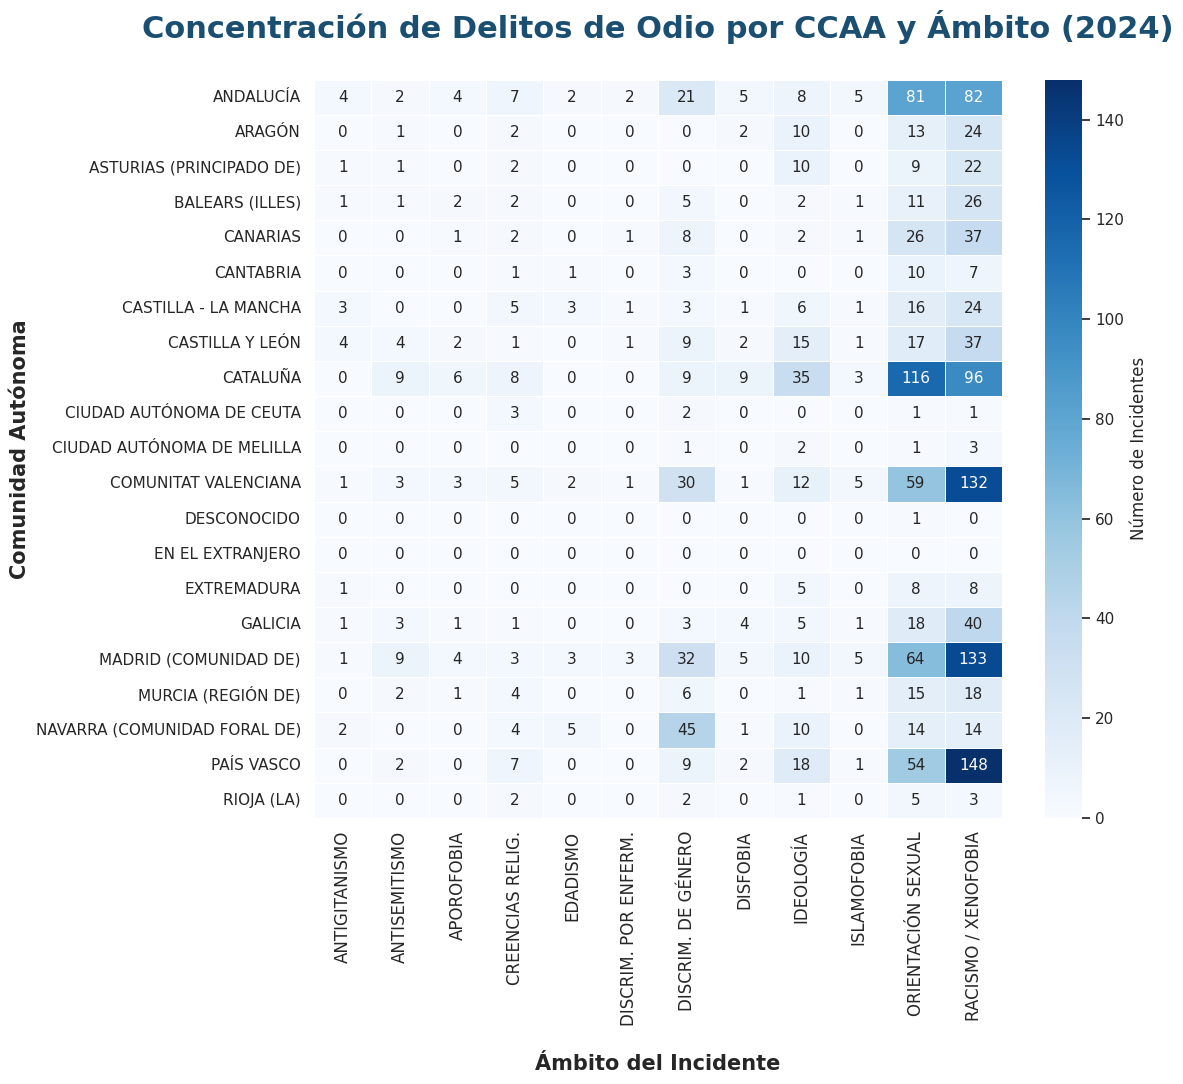

In [7]:
# =============================================================================
# 6. VISUALIZACIÓN: MAPA DE CALOR -> No utilizado en la presentación PPT
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import logging
import warnings

# 6.1 SILENCIAMOS AVISOS DE FUENTES PARA MANTENER EL NOTEBOOK LIMPIO
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=".*font family 'Calibri' not found.*")

# 6.2. PREPARACIÓN Y FILTRADO DE DATOS
df_heatmap = df[
    (df['periodo'] == 2024) &
    (df['Comunidades autónomas'] != f_nacional) &
    (df['Tipología penal'] == f_tipo_total) &
    (df['Ámbito'] != f_ambito_total) &
    (df['Calificación'] == f_calif_total)
]

# 6.3 CREACIÓN DE LA TABLA PIVOT
pivot_heatmap = df_heatmap.pivot_table(
    index='Comunidades autónomas',
    columns='Ámbito',
    values='Total',
    aggfunc='sum'
)

# 6.4. MAPEO DE NOMBRES A VERSIONES CORTAS
mapeo_nombres = {
    'ANTIGITANISMO': 'ANTIGITANISMO',
    'ANTISEMITISMO': 'ANTISEMITISMO',
    'APOROFOBIA': 'APOROFOBIA',
    'CREENCIAS O PRÁCTICAS RELIGIOSAS': 'CREENCIAS RELIG.',
    'DISCRIMINACIÓN GENERACIONAL': 'EDADISMO',
    'DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD': 'DISCRIM. POR ENFERM.',
    'DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO': 'DISCRIM. DE GÉNERO',
    'DISFOBIA': 'DISFOBIA',
    'IDEOLOGIA': 'IDEOLOGÍA',
    'ISLAMOFOBIA': 'ISLAMOFOBIA',
    'ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO': 'ORIENTACIÓN SEXUAL',
    'RACISMO/XENOFOBIA': 'RACISMO / XENOFOBIA'
}

pivot_heatmap = pivot_heatmap.rename(columns=mapeo_nombres)

# 6.5. CONFIGURACIÓN VISUAL DEL HEATMAP
plt.figure(figsize=(12, 11))
sns.set_theme(style="white")

# 6.6. FORZADO DE JERARQUÍA DE FUENTES PARA EVITAR ERRORES VISUALES
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'

# 6.7. MAPA DE CALOR EN ESCALA DE AZULES
ax = sns.heatmap(
    pivot_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=.5,
    cbar_kws={'label': 'Número de Incidentes'},
    annot_kws={"size": 11} # Eliminamos 'family' de aquí para que use el rcParams global
)

# 6.8. TÍTULOS Y ETIQUETAS
plt.title('Concentración de Delitos de Odio por CCAA y Ámbito (2024)',
          fontsize=22,
          pad=30,
          weight='bold',
          color='#1B4F72')

plt.xlabel('Ámbito del Incidente', fontsize=15, weight='bold', labelpad=20)
plt.ylabel('Comunidad Autónoma', fontsize=15, weight='bold')

# 6.9. ROTACIÓN VERTICAL DE ETIQUETAS
plt.xticks(rotation=90, ha='center', fontsize=12)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

**Lectura e interpretación de la visualización**

El mapa de calor permite identificar patrones de concentración territorial de los delitos de odio en función de la comunidad autónoma y del ámbito del incidente para el año 2024. La codificación cromática facilita una lectura comparativa inmediata, destacando aquellas combinaciones comunidad–ámbito donde el número de incidentes es significativamente mayor.

Se observa que ciertas comunidades autónomas concentran valores elevados en tipologías concretas, lo que sugiere una distribución heterogénea del fenómeno a nivel territorial. Este comportamiento refuerza la idea de que los delitos de odio no se manifiestan de forma uniforme en el territorio, sino que responden a dinámicas sociales y contextuales específicas.

Asimismo, el mapa pone de relieve que algunas tipologías presentan una dispersión territorial más amplia, mientras que otras muestran focos muy localizados. Esta diferencia resulta relevante para entender el carácter estructural o puntual de determinadas manifestaciones de odio.

Aunque esta visualización no forma parte del storytelling principal, su análisis aporta una validación exploratoria clave: confirma que los patrones observados a nivel nacional se expresan de manera desigual en el territorio, justificando la necesidad de abordar el fenómeno desde una perspectiva contextual y multidimensional.


### **7. Comparación temporal por ámbito: evolución 2014 vs 2024**

Este bloque introduce una visualización comparativa diseñada para analizar cómo han evolucionado los distintos ámbitos de los delitos de odio entre el inicio y el final del periodo de estudio (2014–2024).

A diferencia de las visualizaciones anteriores, centradas en tendencias agregadas o distribuciones acumuladas, aquí el foco se sitúa en el cambio neto experimentado por cada tipología. El objetivo es responder de forma directa a la pregunta: qué ámbitos han aumentado más —y en qué magnitud— a lo largo de la última década.

Para ello:

- Se filtran los datos a nivel nacional y se seleccionan únicamente los años inicial y final del periodo.
- Se reorganiza la información en una estructura comparativa que permite confrontar ambos valores por ámbito.
- Se utiliza un gráfico tipo *lollipop*, especialmente adecuado para resaltar diferencias absolutas entre dos momentos temporales.
- Se prioriza un diseño minimalista, en el que el protagonismo recae en el desplazamiento entre ambos puntos y en la magnitud del cambio.

Esta visualización permite una lectura rápida e intuitiva de los aumentos y descensos relativos, reforzando el carácter comparativo del análisis.


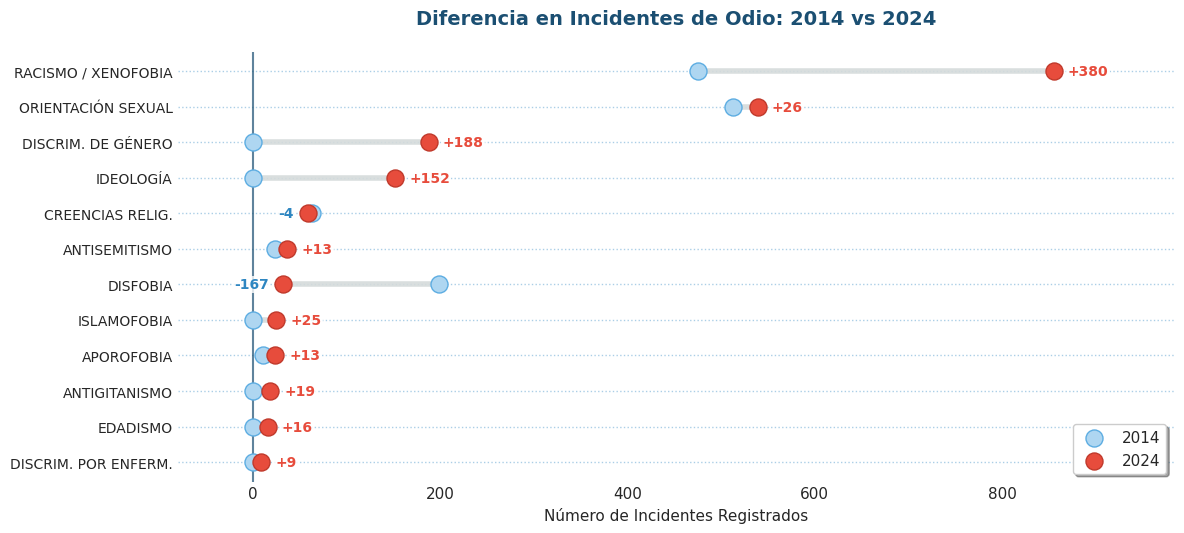

In [8]:
# =============================================================================
# 7. VISUALIZACIÓN: LOLLIPOP CHART
# =============================================================================

import matplotlib.pyplot as plt
import logging
import warnings

# 7.1. SILENCIADO DE AVISOS DE FUENTES
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=".*font family 'Calibri' not found.*")

# 7.2. PREPARACIÓN DE DATOS PARA LA VISUALIZACIÓN
df_comp = df[
    (df['Comunidades autónomas'] == f_nacional) &
    (df['Tipología penal'] == f_tipo_total) &
    (df['Ámbito'] != f_ambito_total) &
    (df['Calificación'] == f_calif_total) &
    (df['periodo'].isin([2014, 2024]))
]

df_lolly = df_comp.pivot_table(index='Ámbito', columns='periodo', values='Total').reset_index()
df_lolly.columns = ['Ámbito', 'y2014', 'y2024']

# 7.3. MAPEO DE NOMBRES CORTOS
mapeo_nombres = {
    'ANTIGITANISMO': 'ANTIGITANISMO',
    'ANTISEMITISMO': 'ANTISEMITISMO',
    'APOROFOBIA': 'APOROFOBIA',
    'CREENCIAS O PRÁCTICAS RELIGIOSAS': 'CREENCIAS RELIG.',
    'DISCRIMINACIÓN GENERACIONAL': 'EDADISMO',
    'DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD': 'DISCRIM. POR ENFERM.',
    'DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO': 'DISCRIM. DE GÉNERO',
    'DISFOBIA': 'DISFOBIA',
    'IDEOLOGIA': 'IDEOLOGÍA',
    'ISLAMOFOBIA': 'ISLAMOFOBIA',
    'ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO': 'ORIENTACIÓN SEXUAL',
    'RACISMO/XENOFOBIA': 'RACISMO / XENOFOBIA'
}
df_lolly['Ámbito'] = df_lolly['Ámbito'].map(mapeo_nombres)
df_lolly = df_lolly.sort_values(by='y2024', ascending=True)

# 7.4. CONFIGURACIÓN DE LA GRÁFICA
plt.figure(figsize=(12, 5.5))
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'

# 7.5. REJILLA Y LÍNEA DE BASE
plt.grid(axis='y', linestyle=':', color='#2E86C1', alpha=0.4, zorder=0)
plt.axvline(x=0, color='#1B4F72', linewidth=1.5, alpha=0.7)

# 7.6. DIBUJO DE ELEMENTOS CON ETIQUETAS MINIMALISTAS
for i, row in df_lolly.iterrows():
    y2014, y2024 = float(row['y2014']), float(row['y2024'])
    diff_absoluta = y2024 - y2014

    # Línea de conexión
    plt.hlines(y=row['Ámbito'], xmin=min(y2014, y2024), xmax=max(y2014, y2024),
               color='#D5DBDB', alpha=0.9, linewidth=4, zorder=1)

    # Formato de etiqueta: Sólo el número con su signo
    signo = "+" if diff_absoluta > 0 else ""
    texto = f"{signo}{int(diff_absoluta)}"

    # Lógica de color y posición
    if diff_absoluta >= 0:
        color_label = '#E74C3C' # Rojo para aumento
        offset = 15
        ha = 'left'
    else:
        color_label = '#2E86C1' # Azul para descenso
        offset = -15
        ha = 'right'

    # Dibujar etiqueta (sin la palabra 'casos')
    plt.text(y2024 + offset, row['Ámbito'], texto,
             va='center', ha=ha, fontsize=10, color=color_label,
             weight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# 7.7. PUNTOS Y ESTÉTICA FINAL
plt.scatter(df_lolly['y2014'], df_lolly['Ámbito'], color='#AED6F1', label='2014', s=150, edgecolors='#5DADE2', zorder=3)
plt.scatter(df_lolly['y2024'], df_lolly['Ámbito'], color='#E74C3C', label='2024', s=150, edgecolors='#C0392B', zorder=3)

plt.title('Diferencia en Incidentes de Odio: 2014 vs 2024',
          fontsize=14, pad=20, weight='bold', color='#1B4F72')

plt.xlabel('Número de Incidentes Registrados', fontsize=11)
plt.yticks(fontsize=10)
plt.legend(loc='lower right', frameon=True, shadow=True)

# 7.8. AJUSTE DE LÍMITES DINÁMICO
plt.xlim(min(0, df_lolly['y2024'].min()) - 80, df_lolly['y2024'].max() * 1.15)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Lectura e interpretación de la visualización**

La visualización muestra de forma clara que el aumento de los delitos de odio entre 2014 y 2024 no se reparte de manera uniforme entre los distintos ámbitos, sino que se concentra en tipologías concretas con incrementos muy significativos.

Destaca especialmente el ámbito de racismo y xenofobia, que presenta el mayor aumento absoluto del periodo, consolidándose como el principal motor del crecimiento global observado en los bloques anteriores. Este incremento refuerza la lectura de un fenómeno estructural y persistente en el tiempo.

También se observan aumentos relevantes en los ámbitos de discriminación por razón de sexo/género e ideología, así como en orientación sexual e identidad de género, lo que apunta a una intensificación de conflictos ligados a identidades y valores sociales fundamentales.

En contraste, otras tipologías presentan incrementos más moderados, e incluso descensos puntuales, lo que evidencia que no todos los ámbitos evolucionan con la misma intensidad ni responden de igual forma a los cambios sociales del periodo analizado.

La comparación directa entre 2014 y 2024 permite sintetizar una década de evolución en una única imagen, facilitando una lectura inmediata del impacto acumulado por ámbito. Este resultado refuerza la necesidad de analizar factores contextuales —como el nivel educativo y la concienciación social— para comprender por qué determinadas tipologías concentran los mayores aumentos.


### **8. Distribución geográfica normalizada de los delitos de odio (tasa por 100.000 habitantes)**

Este bloque introduce una visualización geográfica orientada a analizar la distribución territorial de los delitos de odio en España para el año 2024, incorporando un ajuste fundamental: la normalización por población.

A diferencia de los análisis previos basados en valores absolutos, esta visualización busca responder a una pregunta distinta: en qué territorios la incidencia relativa del fenómeno es mayor, una vez corregido el efecto del tamaño poblacional de cada comunidad autónoma.

Para ello:

- Se agregan los incidentes a nivel autonómico, manteniendo el mismo criterio metodológico aplicado en el resto del notebook.
- Se incorporan datos de población para calcular la tasa de delitos de odio por cada 100.000 habitantes.
- Se integran los datos estadísticos con una geometría territorial en formato GeoJSON.
- Se ajusta manualmente la posición de territorios no peninsulares para mejorar la legibilidad del mapa.
- Se emplea una escala cromática discreta, diseñada para facilitar comparaciones claras entre rangos de incidencia y evitar interpretaciones ambiguas.

Esta visualización permite pasar de una lectura cuantitativa o tipológica a una interpretación espacial del fenómeno, aportando una dimensión clave al storytelling.


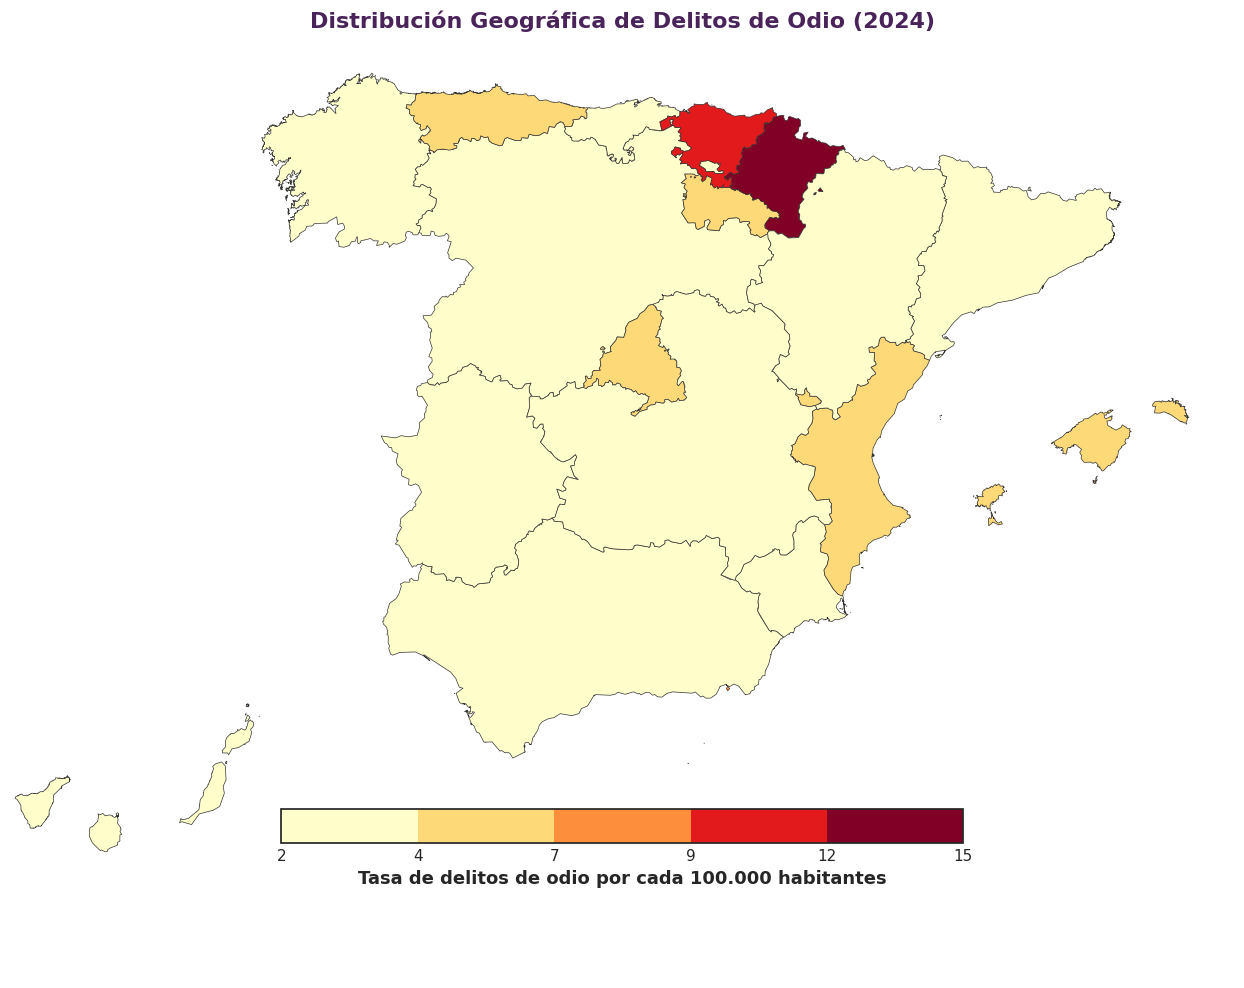

In [9]:
# =============================================================================
# 8. VISUALIZACIÓN: MAPA PRO CON BARRA DISCRETA Y ENCUADRE CORREGIDO
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# 8.1. PREPARACIÓN DE DATOS PARA LA VISUALIZACIÓN Preparación de datos
poblacion_ccaa = {
    'ANDALUCÍA': 8500000, 'ARAGÓN': 1330000, 'ASTURIAS (PRINCIPADO DE)': 1010000,
    'BALEARS (ILLES)': 1170000, 'CANARIAS': 2170000, 'CANTABRIA': 585000,
    'CASTILLA Y LEÓN': 2380000, 'CASTILLA - LA MANCHA': 2050000, 'CATALUÑA': 7700000,
    'COMUNITAT VALENCIANA': 5050000, 'EXTREMADURA': 1060000, 'GALICIA': 2700000,
    'MADRID (COMUNIDAD DE)': 6750000, 'MURCIA (REGIÓN DE)': 1510000,
    'NAVARRA (COMUNIDAD FORAL DE)': 660000, 'PAÍS VASCO': 2200000, 'RIOJA (LA)': 320000,
    'CIUDAD AUTÓNOMA DE CEUTA': 84000, 'CIUDAD AUTÓNOMA DE MELILLA': 86000
}

traductor_mapa = {
    'ANDALUCÍA': 'Andalucia', 'ARAGÓN': 'Aragon', 'ASTURIAS (PRINCIPADO DE)': 'Asturias',
    'BALEARS (ILLES)': 'Baleares', 'CANARIAS': 'Canarias', 'CANTABRIA': 'Cantabria',
    'CASTILLA Y LEÓN': 'Castilla-Leon', 'CASTILLA - LA MANCHA': 'Castilla-La Mancha',
    'CATALUÑA': 'Cataluña', 'COMUNITAT VALENCIANA': 'Valencia', 'EXTREMADURA': 'Extremadura',
    'GALICIA': 'Galicia', 'MADRID (COMUNIDAD DE)': 'Madrid', 'MURCIA (REGIÓN DE)': 'Murcia',
    'NAVARRA (COMUNIDAD FORAL DE)': 'Navarra', 'PAÍS VASCO': 'Pais Vasco', 'RIOJA (LA)': 'La Rioja',
    'CIUDAD AUTÓNOMA DE CEUTA': 'Ceuta', 'CIUDAD AUTÓNOMA DE MELILLA': 'Melilla'
}

# 8.2. MISMO CRITERIO QUE EL RESTO DEL NOTEBOOK (NO TOTAL)
df_mapa_data = df[
    (df['periodo'] == 2024) &
    (df['Comunidades autónomas'].isin(poblacion_ccaa.keys())) &
    (df['Tipología penal'] == f_tipo_total) &
    (df['Ámbito'] != f_ambito_total) &
    (df['Calificación'] == f_calif_total)
].copy()

# 8.3. AGREGACIÓN POR CCAA (SUMA DE COLECTIVOS)
df_mapa_data = (
    df_mapa_data
    .groupby('Comunidades autónomas', as_index=False)['Total']
    .sum()
)

df_mapa_data['Tasa_100k'] = (
    df_mapa_data['Total'] /
    df_mapa_data['Comunidades autónomas'].map(poblacion_ccaa)
) * 100000

df_mapa_data['nombre_geojson'] = df_mapa_data['Comunidades autónomas'].map(traductor_mapa)

# 8.4. GEOMETRÍA Y REUBICACIONES
url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/master/public/data/spain-communities.geojson"
spain = gpd.read_file(url)

spain.loc[spain['name'] == 'Canarias', 'geometry'] = (
    spain[spain['name'] == 'Canarias'].geometry.translate(xoff=4, yoff=7.2)
)
spain.loc[spain['name'] == 'Ceuta', 'geometry'] = (
    spain[spain['name'] == 'Ceuta'].geometry.translate(xoff=1.5, yoff=1)
)
spain.loc[spain['name'] == 'Melilla', 'geometry'] = (
    spain[spain['name'] == 'Melilla'].geometry.translate(xoff=0.5, yoff=1.5)
)

world = spain.merge(
    df_mapa_data,
    left_on='name',
    right_on='nombre_geojson',
    how='left'
)

# 8.5. CCAA sin registros = 0
world['Tasa_100k'] = world['Tasa_100k'].fillna(0)

# 8.6. LEYENDA DISCRETA EXACTA
bounds = [2, 4, 7, 9, 12, 15]

cmap = plt.get_cmap('YlOrRd')
norm = mcolors.BoundaryNorm(bounds, cmap.N, clip=True)

# 8.7. CONSTRUCCIÓN DEL GRÁFICO FINAL
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

world.plot(
    column='Tasa_100k',
    ax=ax,
    cmap=cmap,
    norm=norm,
    edgecolor='0.2',
    linewidth=0.5
)

# Barra horizontal discreta
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = fig.colorbar(
    sm,
    ax=ax,
    orientation='horizontal',
    shrink=0.5,
    pad=-0.19,
    ticks=bounds
)

cb.set_label(
    "Tasa de delitos de odio por cada 100.000 habitantes",
    fontsize=13,
    fontweight='bold'
)
cb.ax.set_xticklabels([str(b) for b in bounds])

# Encuadre y título
ax.set_ylim(33.5, 44)
ax.set_xlim(-13, 5)

ax.set_title(
    'Distribución Geográfica de Delitos de Odio (2024)',
    fontsize=16,
    weight='bold',
    color='#4A235A',
    pad=20
)

ax.set_axis_off()

plt.tight_layout()
plt.show()



**Lectura e interpretación de la visualización**

La visualización pone de manifiesto que la distribución de los delitos de odio en 2024 presenta una clara heterogeneidad territorial cuando se analiza en términos de tasa por cada 100.000 habitantes. La normalización poblacional permite identificar comunidades donde la incidencia relativa es especialmente elevada, independientemente de su tamaño demográfico.

Se observa que algunas comunidades destacan con tasas significativamente superiores al resto, configurándose como focos de mayor intensidad relativa del fenómeno. Este patrón contrasta con otras regiones que, pese a registrar incidentes en valores absolutos, presentan tasas bajas una vez ajustadas por población.

El uso de una escala discreta facilita la identificación de rangos de incidencia y evita interpretaciones excesivamente finas que no estarían justificadas por la naturaleza del dato. La lectura resultante es clara: el fenómeno no se distribuye de forma uniforme en el territorio y presenta concentraciones espaciales bien definidas.

Este análisis geográfico refuerza la idea de que los delitos de odio deben abordarse desde una perspectiva contextual, donde factores sociales, demográficos y culturales pueden estar influyendo de manera diferenciada según el territorio. Con ello, el storytelling visual integra definitivamente la dimensión espacial como una pieza clave para comprender la complejidad del fenómeno.


### **9. Diagrama conceptual: puente social–institucional**

Este bloque introduce un diagrama conceptual que actúa como elemento de transición entre las dos partes principales del análisis. Su objetivo no es representar datos empíricos, sino sintetizar de forma visual el marco interpretativo que conecta los procesos sociales analizados hasta ahora con la dimensión institucional que se abordará a continuación.

Tras haber explorado la evolución temporal, la distribución por tipologías y la dimensión territorial de los delitos de odio, este diagrama permite explicitar el vínculo entre el origen social del fenómeno y su traducción en mecanismos formales de identificación y registro.

La visualización se estructura en tres niveles:

- Un plano superior de carácter social, donde se representa la progresión desde el odio hasta la discriminación.
- Un elemento mediador central, que sitúa la educación y la conciencia social como factor clave de transformación.
- Un plano inferior institucional, que recoge el proceso formal de identificación, denuncia y registro de los incidentes.

Este esquema funciona como marco conceptual de referencia para la segunda parte del trabajo, facilitando la transición desde el análisis descriptivo hacia la interpretación de los mecanismos que condicionan la visibilización y medición del fenómeno.


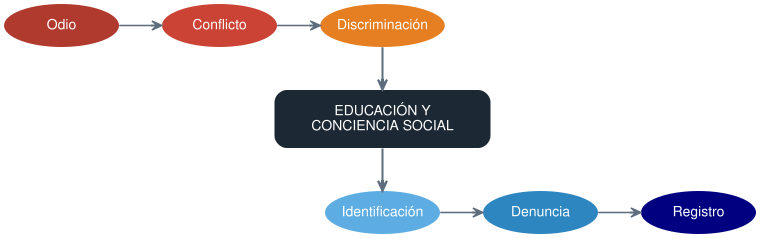

In [10]:
# =============================================================================
# 9. DIAGRAMA DE FLUJO: PUENTE SOCIAL-INSTITUCIONAL
# =============================================================================

# 9.1. IMPORTACIÓN DE GRAPHVIZ
import graphviz

# 9.2. CREACIÓN DEL DIAGRAMA
dot = graphviz.Digraph(comment='Flujo Corregido', format='png')

# 9.3. CONFIGURACIÓN DEL ESTILO
dot.attr(rankdir='TB', nodesep='0.6', ranksep='0.6', fontname='Helvetica')
dot.attr('node', fontname='Helvetica', style='filled, rounded',
         fontcolor='white', penwidth='0', width='1.6', height='0.6')
dot.attr('edge', color='#5D6D7E', penwidth='1.5', arrowhead='vee')

# 9.4. FILA SUPERIOR: PLANO SOCIAL (GRADIENTE ROJO)
with dot.subgraph() as s:
    s.attr(rank='same')
    s.node('1', 'Odio', fillcolor='#B03A2E')          # Rojo intenso
    s.node('2', 'Conflicto', fillcolor='#CB4335')     # Rojo medio
    s.node('3', 'Discriminación', fillcolor='#E67E22') # Rojo suave
    s.edge('1', '2')
    s.edge('2', '3')

# 9.5. CAJA MEDIADORA CENTRAL (GRIS OSCURO)
dot.node('B', 'EDUCACIÓN Y\nCONCIENCIA SOCIAL',
         shape='box', fillcolor='#1C2833', fontcolor='white',
         width='3.0', height='0.8', style='filled, rounded, bold')

# 9.6. FILA INFERIOR: PLANO INSTITUCIONAL (GRADIENTE AZUL)
with dot.subgraph() as i:
    i.attr(rank='same')
    i.node('4', 'Identificación', fillcolor='#5DADE2') # Azul suave
    i.node('5', 'Denuncia', fillcolor='#2E86C1')        # Azul medio
    i.node('6', 'Registro', fillcolor='#000080')        # Azul intenso
    i.edge('4', '5')
    i.edge('5', '6')

# 9.7 CONEXIONES VERTICALES
dot.edge('3', 'B', penwidth='2.0') # De Discriminación a Educación
dot.edge('B', '4', penwidth='2.0') # De Educación a Identificación

# 9.8. RENDERIZACIÓN
dot

**Lectura e interpretación del diagrama**

El diagrama representa un flujo conceptual que conecta el plano social con el plano institucional, mostrando cómo los fenómenos de odio no se traducen automáticamente en datos registrados, sino que atraviesan una serie de mediaciones.

En el plano superior se muestra una progresión social —odio, conflicto y discriminación— que describe un proceso de intensificación del rechazo hacia determinados colectivos. Este recorrido refleja dinámicas sociales que pueden existir incluso sin una manifestación formal o visible en los sistemas institucionales.

La inclusión de la educación y la conciencia social como nodo central subraya su papel clave como elemento transformador. Este bloque actúa como un filtro y catalizador: condiciona la capacidad de identificar una situación como discriminatoria y de reconocerla como un hecho denunciable.

En el plano inferior se representa el proceso institucional —identificación, denuncia y registro— que convierte una experiencia social en un dato oficial. La direccionalidad del flujo enfatiza que este proceso depende en gran medida del paso previo por el nodo educativo, y que sin él muchos casos pueden quedar invisibilizados.

Este diagrama establece así el marco lógico que justifica la segunda parte del trabajo, en la que se analiza cómo variables estructurales, como el nivel educativo, pueden influir no solo en la prevención del odio, sino también en su detección, denuncia y registro estadístico.


### **10. Carga y exploración del dataset de contexto social y educativo**

Con este bloque se inicia la segunda parte del análisis, centrada en la incorporación de variables de contexto social que permitan enriquecer la interpretación de los patrones observados en los delitos de odio.

El dataset utilizado procede de una fuente institucional europea y recoge información sobre la población de entre 25 y 64 años desglosada por país, nivel de formación y grado de urbanización. Estas variables resultan especialmente relevantes para el enfoque del proyecto, ya que permiten aproximarse al papel del contexto educativo y social en la comprensión del fenómeno analizado.

En este bloque se realizan las siguientes operaciones iniciales:

- Carga del archivo de datos utilizando una codificación y separador adecuados al formato original.
- Normalización de los nombres de las columnas para facilitar su manipulación posterior.
- Conversión de la variable cuantitativa principal a formato numérico, gestionando correctamente el uso de separadores decimales europeos.
- Exploración preliminar de la estructura del dataset, con especial atención a las categorías de nivel de formación y grado de urbanización.

Esta fase de exploración permite validar la calidad del dataset de contexto y preparar el terreno para los cruces y análisis comparativos que se desarrollarán en los siguientes bloques.


In [11]:
# =============================================================================
# 10. CARGA Y EXPLORACIÓN DEL DATASET DE CONTEXTO SOCIAL (URBANIZACIÓN/EDUCACIÓN)
# =============================================================================

import pandas as pd

# 10.1. NOMBRE DEL ARCHIVO
file_contexto = '../data/nivfor_1_04.csv'

# 10.2. ORIGEN DEL DATASET
# Ministerio para la Transformación Digital y de la Función Pública (Gobierno de España)
# Población de 25 a 64 años en la UE por país, sexo, nivel de formación, grado de urbanización y año
# https://datos.gob.es/es/catalogo/e05230301-poblacion-de-25-a-64-anos-en-la-ue-por-pais-sexo-nivel-de-formacion-grado-de-urbanizacion-y-ano

# 10.3. EXPLORACIÓN DEL DATASET
try:
    # 1. Carga con codificación robusta y separador de punto y coma
    df_ue = pd.read_csv(file_contexto, sep=';', encoding='utf-8-sig')

    # 2. Limpieza de nombres de columnas
    df_ue.columns = [col.strip() for col in df_ue.columns]

    # 3. Conversión de 'Total' a numérico (manejo de comas decimales europeas)
    if df_ue['Total'].dtype == 'object':
        df_ue['Total'] = df_ue['Total'].str.replace('.', '', regex=False) # Quitar puntos de miles si existen
        df_ue['Total'] = df_ue['Total'].str.replace(',', '.', regex=False) # Cambiar coma decimal por punto
        df_ue['Total'] = pd.to_numeric(df_ue['Total'], errors='coerce')

    print(f"✅ Archivo '{file_contexto}' cargado y procesado.")
    print("-" * 30)

    # --- INSPECCIÓN DE ESTRUCTURA NUEVA ---
    print(f"Columnas detectadas en este dataset:")
    print(df_ue.columns.tolist())

    print("\nCategorías en 'Grado de urbanización':")
    print(df_ue['Grado de urbanización'].unique())

    print("\nCategorías en 'Nivel de formación':")
    print(df_ue['Nivel de formación'].unique())

    # Visualización
    display(df_ue.head(10))

except Exception as e:
    print(f"❌ Error al cargar el archivo de contexto: {e}")

# Variables nuevas disponibles: df_ue, file_contexto

✅ Archivo '../data/nivfor_1_04.csv' cargado y procesado.
------------------------------
Columnas detectadas en este dataset:
['Sexo', 'País', 'Nivel de formación', 'Grado de urbanización', 'periodo', 'Total']

Categorías en 'Grado de urbanización':
['TOTAL' 'Áreas densamente pobladas' 'Áreas intermedias'
 'Áreas escasamente pobladas']

Categorías en 'Nivel de formación':
['1ª etapa E. Secundaria o inferior' '2ª etapa E. Secundaria'
 'E. Superior']


,Sexo,País,Nivel de formación,Grado de urbanización,periodo,Total
0,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2024,19.6
1,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2023,20.2
2,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2022,20.6
3,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2021,21.0
4,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2020,21.0
5,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2019,21.5
6,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2018,22.2
7,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2017,22.8
8,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2016,23.4
9,AMBOS SEXOS,Unión Europea (27 países),1ª etapa E. Secundaria o inferior,TOTAL,2015,23.9


### **11. Comparativa del nivel educativo superior: España en el contexto de la Unión Europea (2024)**

Este bloque introduce la primera visualización orientada explícitamente al análisis del contexto educativo, con el objetivo de situar a España dentro del marco comparativo de la Unión Europea en términos de nivel de formación superior.

La variable analizada corresponde al porcentaje de población de entre 25 y 64 años con educación superior, un indicador ampliamente utilizado para aproximar el capital educativo de una sociedad. En el contexto de este proyecto, este dato se incorpora como variable estructural de referencia, no como explicación directa, sino como parte del marco que permite interpretar los patrones observados en los delitos de odio.

Para ello:

- Se filtran los datos correspondientes al año 2024, nivel de formación superior y total de grado de urbanización.
- Se utiliza la media de la Unión Europea (27 países) como referencia comparativa.
- Se construye una visualización que distingue visualmente entre el tramo hasta la media europea y el excedente por encima de esta, facilitando una lectura inmediata de las diferencias relativas.
- Se resalta específicamente el caso de España para focalizar el análisis sin perder el contexto comparado.

Esta visualización establece el punto de partida para analizar la relación entre educación, contexto social y los fenómenos estudiados en la segunda parte del trabajo.


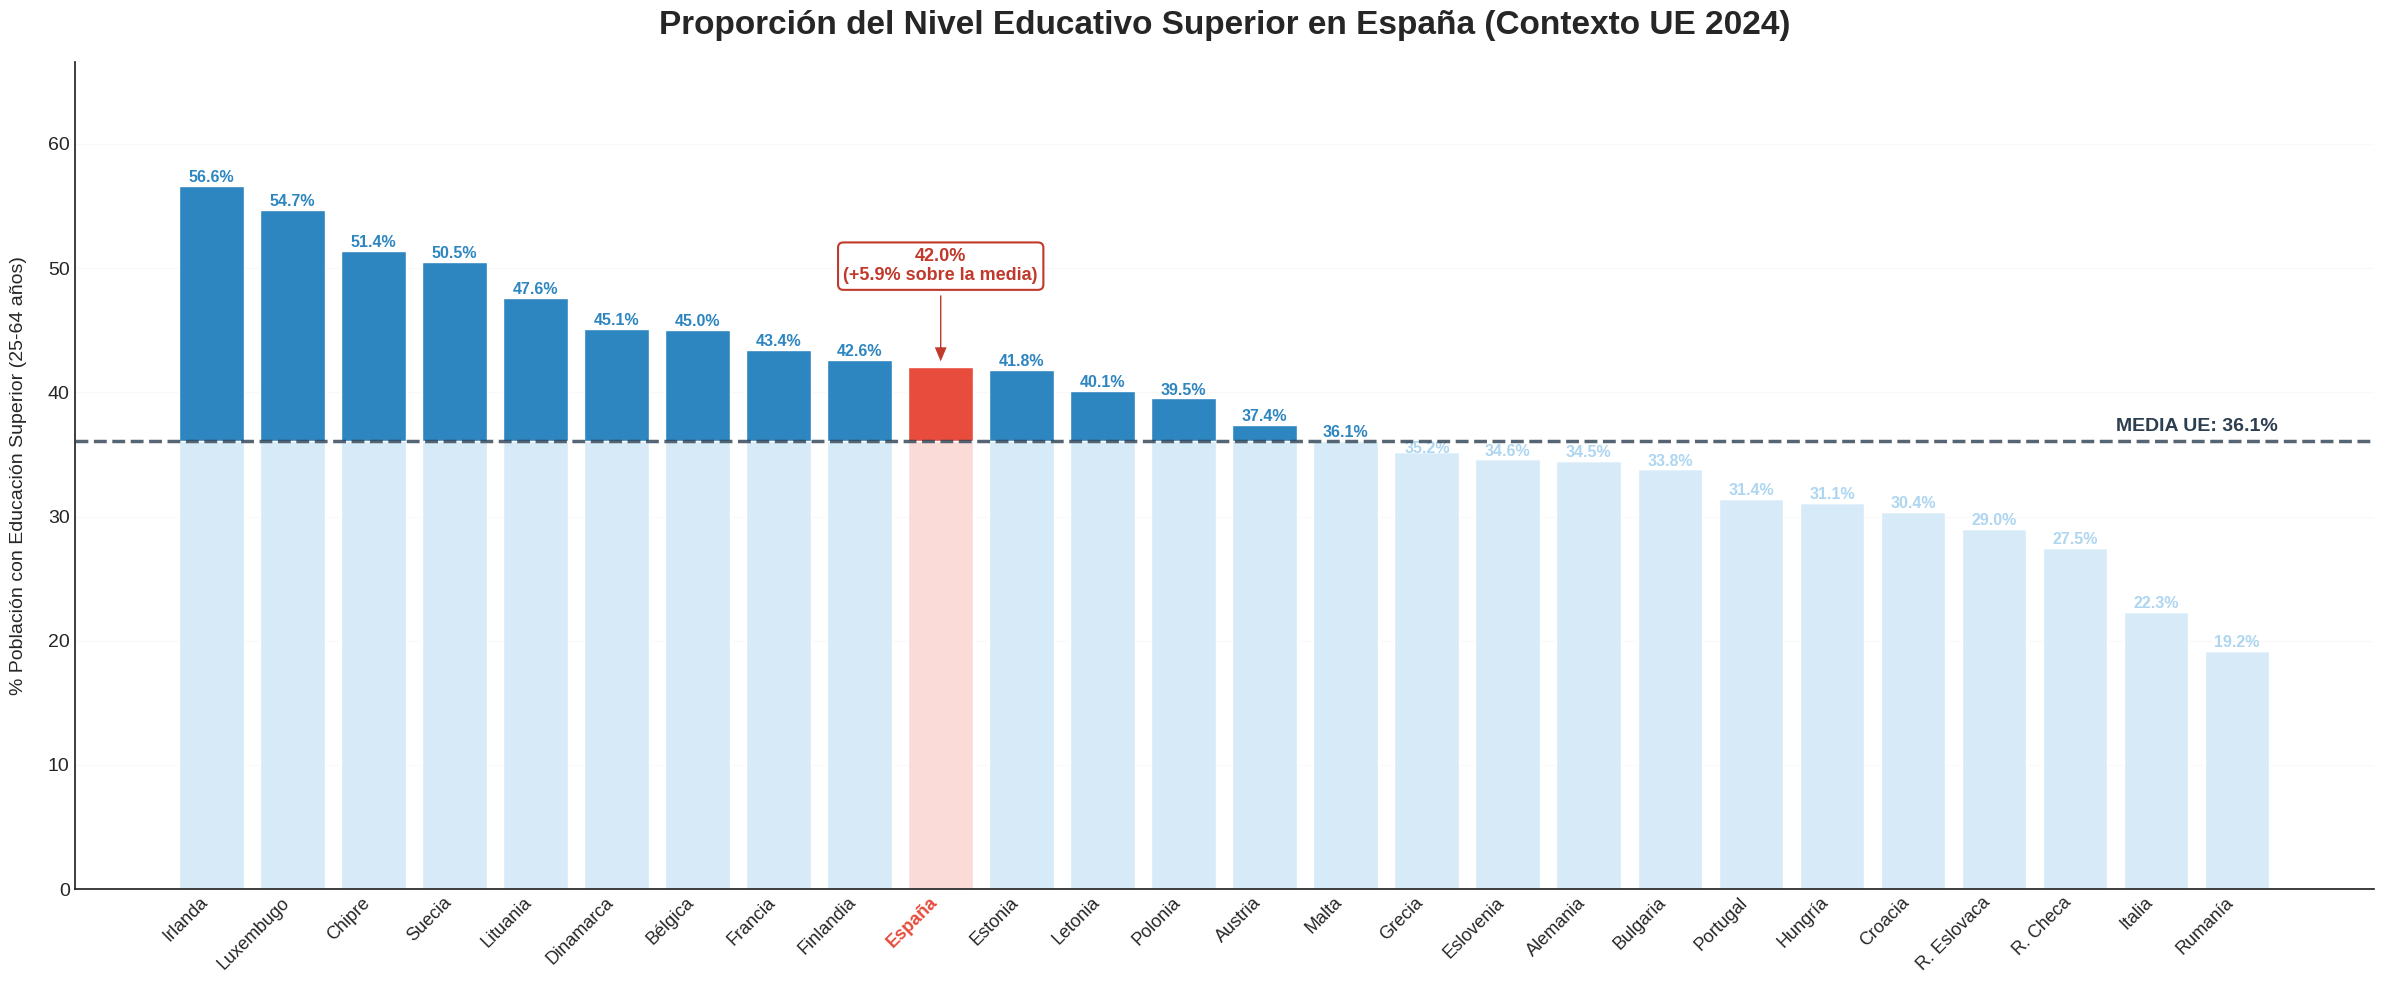

In [12]:
# =============================================================================
# 11. VISUALIZACIÓN: COMPARATIVA EDUCACIÓN SUPERIOR ESPAÑA VS UE (2024)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# 11.1. PREPARACIÓN DE DATOS
# Creamos una columna auxiliar para el gráfico sin afectar el df_ue original
df_plot_ue = df_ue.copy()
df_plot_ue['Total_num'] = pd.to_numeric(df_plot_ue['Total'].astype(str).str.replace(',', '.'), errors='coerce')

# 11.2. REFERENCIA MEDIA UE
try:
    media_ue_row = df_plot_ue[
        (df_plot_ue['País'] == 'Unión Europea (27 países)') &
        (df_plot_ue['periodo'] == 2024) &
        (df_plot_ue['Nivel de formación'] == 'E. Superior') &
        (df_plot_ue['Grado de urbanización'] == 'TOTAL') &
        (df_plot_ue['Sexo'] == 'AMBOS SEXOS')
    ]
    media_ue = media_ue_row['Total_num'].values[0]
except IndexError:
    print("⚠️ Error: No se encontró la fila de 'Unión Europea (27 países)'. Revisa los filtros.")
    media_ue = 0

# 11.3. FILTRADO DE PAISES (LOS 27 MIEMBROS INDIVIDUALES)
df_paises = df_plot_ue[
    (df_plot_ue['periodo'] == 2024) &
    (df_plot_ue['Nivel de formación'] == 'E. Superior') &
    (df_plot_ue['Grado de urbanización'] == 'TOTAL') &
    (df_plot_ue['Sexo'] == 'AMBOS SEXOS') &
    (~df_plot_ue['País'].str.contains('Unión Europea|países', na=False, case=False))
].dropna(subset=['Total_num']).sort_values('Total_num', ascending=False)

# 11.4. DATOS PARA EL EFECTO DE APILADO CONDICIONAL
df_paises['Base'] = df_paises['Total_num'].apply(lambda x: min(x, media_ue))
df_paises['Excedente'] = df_paises['Total_num'].apply(lambda x: max(0, x - media_ue))

# 11.5. VISUALIZACIÓN
plt.figure(figsize=(24, 10))
plt.style.use('seaborn-v0_8-white')

# Dibujamos BASE y EXCEDENTE con colores temáticos
colores_base = ['#FADBD8' if p == 'España' else '#D6EAF8' for p in df_paises['País']]
plt.bar(df_paises['País'], df_paises['Base'], color=colores_base, label='Base (Hasta media UE)')

colores_excedente = ['#E74C3C' if p == 'España' else '#2E86C1' for p in df_paises['País']]
plt.bar(df_paises['País'], df_paises['Excedente'], bottom=df_paises['Base'], color=colores_excedente)

# Línea de la Media UE
plt.axhline(y=media_ue, color='#2C3E50', linestyle='--', linewidth=2.5, zorder=5, alpha=0.8)
plt.text(len(df_paises)-0.5, media_ue + 0.8, f'MEDIA UE: {media_ue:.1f}%',
         color='#2C3E50', fontweight='bold', fontsize=14, ha='right')

# 11.6. ETIQUETAS ESPECIALES Y ANOTACIONES
val_esp = df_paises[df_paises['País'] == 'España']['Total_num'].values[0]
diff_esp = val_esp - media_ue

for i, (pais, val) in enumerate(zip(df_paises['País'], df_paises['Total_num'])):
    if pais == 'España':
        plt.annotate(f'{val:.1f}%\n({diff_esp:+.1f}% sobre la media)',
                     xy=(i, val), xytext=(i, val + 7),
                     arrowprops=dict(facecolor='#C0392B', shrink=0.05, width=2, headwidth=10),
                     ha='center', fontsize=13, fontweight='bold', color='#C0392B',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#C0392B", lw=1.5))
    else:
        separacion = -0.05 if pais == 'Grecia' else 0.3
        color_txt = '#2E86C1' if val >= media_ue else '#AED6F1'
        plt.text(i, val + separacion, f'{val:.1f}%', ha='center', fontsize=11.5, fontweight='bold', color=color_txt)

# 11.7. ESTÉTICA Y FORMATO FINAL
plt.title('Proporción del Nivel Educativo Superior en España (Contexto UE 2024)', fontsize=24, pad=20, fontweight='bold')
plt.ylabel('% Población con Educación Superior (25-64 años)', fontsize=14, labelpad=15)
plt.yticks(fontsize=14)

# 11.8. FORMATEAR ETIQUETAS DEL EJE X
for tick in plt.gca().get_xticklabels():
    if tick.get_text() == 'España':
        tick.set_fontweight('bold')
        tick.set_color('#E74C3C')
plt.xticks(rotation=45, ha='right', fontsize=13)

plt.grid(axis='y', alpha=0.1)
plt.ylim(0, df_paises['Total_num'].max() + 10) # Aumentado el margen superior para la etiqueta de España
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

**Lectura e interpretación de la visualización**

La gráfica sitúa a España en una posición claramente superior a la media de la Unión Europea en cuanto a proporción de población de entre 25 y 64 años con educación superior en 2024. Con un valor aproximado del 42 %, España se encuentra varios puntos porcentuales por encima de la media comunitaria, fijada en torno al 36 %.

La ordenación de los países revela una notable dispersión dentro del contexto europeo: mientras algunos Estados presentan niveles muy elevados de educación superior, otros se sitúan significativamente por debajo de la media. Esta heterogeneidad confirma que el capital educativo constituye una variable estructural fuertemente condicionada por factores históricos, económicos y sociales propios de cada país.

El caso español resulta especialmente relevante dentro del marco del proyecto. Su posición por encima de la media europea contrasta con el incremento sostenido de determinados tipos de delitos de odio observado en los bloques anteriores. Esta coexistencia pone de relieve que un mayor nivel educativo agregado no implica, por sí solo, una reducción automática de estos fenómenos.

Lejos de sugerir una relación causal directa, esta visualización refuerza una lectura contextual: la educación debe entenderse como un factor mediador complejo, que puede influir tanto en la prevención de actitudes discriminatorias como en la capacidad de identificación, denuncia y registro de los delitos de odio. Esta doble dimensión será explorada en los siguientes bloques del análisis.


### **12. Carga y exploración del dataset PISA: conciencia social y entorno educativo**

Con este bloque se incorpora una nueva fuente de datos orientada a profundizar en la dimensión social y educativa del análisis: el cuestionario escolar de PISA 2022. A diferencia de los datasets utilizados hasta ahora, este conjunto de datos no describe resultados académicos ni niveles de formación, sino percepciones, prácticas y contextos institucionales dentro de los centros educativos.

El objetivo de introducir PISA en esta fase del trabajo es explorar indicadores relacionados con la conciencia social, el clima escolar y la diversidad, que pueden actuar como variables intermedias entre educación formal y fenómenos sociales más amplios, como la identificación y visibilización de conductas discriminatorias.

En este bloque se realizan las siguientes operaciones iniciales:

- Carga del archivo de datos en formato SPSS, utilizando una librería específica para garantizar la correcta lectura del dataset.
- Separación explícita de este conjunto de datos respecto a los utilizados anteriormente, evitando solapamientos conceptuales y técnicos.
- Inspección de la estructura general del dataset, incluyendo número de centros educativos y volumen de variables disponibles.
- Exploración preliminar del diccionario de variables, con el fin de identificar aquellas relacionadas con conciencia social, inclusión, convivencia y entorno escolar.

Esta fase de exploración es imprescindible para seleccionar de forma rigurosa las variables de PISA que se utilizarán en los análisis posteriores, y permite conectar el enfoque educativo del proyecto con dimensiones más cualitativas y contextuales del fenómeno estudiado.


In [13]:
# =============================================================================
# 12. CARGA DE DATOS PISA: CONCIENCIA SOCIAL Y ENTORNO ESCOLAR
# =============================================================================

!pip install pyreadstat
import pandas as pd
import pyreadstat

# 12.1. NOMBRE DEL ARCHIVO
file_pisa = '../data/CY08MSP_SCH_QQQ.SAV'

# 12.2. ORIGEN DEL DATASET
# OECD - PISA 2022
# School questionnaire data file
# https://webfs.oecd.org/pisa2022/index.html

# 12.3. EXPLORACIÓN DEL DATASET
try:
    # Cargamos el archivo usando una variable específica (df_pisa)
    # para NO sobrescribir el 'df' de delitos de odio.
    df_pisa, meta_pisa = pyreadstat.read_sav(file_pisa)

    print(f"✅ ¡Logrado! Dataset PISA cargado correctamente.")
    print(f"Dimensiones: {df_pisa.shape[0]} centros educativos x {df_pisa.shape[1]} variables.")
    print("-" * 30)

    # Diccionario de etiquetas para entender qué significan los códigos de las columnas
    variable_labels_pisa = meta_pisa.column_names_to_labels

    print("Muestra de variables detectadas (Primeras 15):")
    # Iteramos sobre las etiquetas para identificar las de interés social/educativo
    for i, (code, label) in enumerate(variable_labels_pisa.items()):
        if i < 15:
            print(f"- {code}: {label}")
        else:
            break

except Exception as e:
    print(f"❌ Error al cargar el archivo de PISA: {e}")
    print("Necesario tener instalada la librería 'pyreadstat' (pip install pyreadstat).")

# Variables nuevas disponibles: df_pisa, meta_pisa, variable_labels_pisa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 89.6 MB/s eta 0:00:00
✅ ¡Logrado! Dataset PISA cargado correctamente.
Dimensiones: 21629 centros educativos x 431 variables.
------------------------------
Muestra de variables detectadas (Primeras 15):
- CNT: Country code 3-character
- CNTRYID: Country Identifier
- CNTSCHID: Intl. School ID
- CYC: PISA Assessment Cycle (2 digits + 2 character Assessment type - MS/FT)
- NatCen: National Centre 6-digit Code
- STRATUM: Stratum ID 5-character (cnt + original stratum ID)
- SUBNATIO: Adjudicated sub-region code 7-digit code (3-digit country code + region ID + stratum ID)
- REGION: REGION
- OECD: OECD country
- ADMINMODE: Mode of Respondent
- LANGTEST_QQQ: Language of Questionnaire
- SC001Q01TA: Which of the following definitions best describes the community in which your school is located?
- SC013Q01TA: Is your school a public or a private school?
- SC014Q01TA: What kind of organisation runs your school?
- SC016Q01TA: Percentage of scho

### **13. Identificación dirigida de variables relacionadas con conciencia social (PISA)**

Una vez cargado y explorado el dataset PISA, este bloque se centra en la identificación sistemática de variables potencialmente relevantes para el análisis de la conciencia social, la diversidad y el entorno escolar.

Dado el elevado número de variables disponibles en el cuestionario escolar de PISA, resulta necesario aplicar un criterio de selección que sea reproducible y conceptualmente justificado. Para ello, se adopta una estrategia de filtrado semántico basada en palabras clave asociadas a discriminación, diversidad cultural, convivencia y multiculturalidad.

En este bloque:

- Se definen términos clave en inglés alineados con los conceptos teóricos del proyecto.
- Se recorren las etiquetas descriptivas de las variables del cuestionario escolar, evitando depender únicamente de los códigos técnicos.
- Se identifican y almacenan aquellas variables cuyas descripciones contienen referencias explícitas a discriminación, diversidad, religión, etnicidad o acoso.
- Se realiza una primera inspección de los valores asociados a las variables seleccionadas.

Este procedimiento permite construir un subconjunto de variables coherente con el marco conceptual del trabajo, sentando las bases para su posterior depuración, agregación y uso en análisis comparativos o correlacionales.


In [14]:
# =============================================================================
# 13. BÚSQUEDA FILTRADA DE VARIABLES DE CONCIENCIA SOCIAL (PISA)
# =============================================================================

# 13.1. DEFINIMOS LOS TÉRMINOS DE BÚSQUEDA EN INGLÉS
terminos_clave = ["discriminat", "cultural", "ethnic", "religion", "diversity", "bullying", "multicultural"]

print(f"--- Buscando variables relacionadas en el dataset PISA ---")
print(f"Palabras clave: {', '.join(terminos_clave)}")
print("-" * 50)

# 13.2. CREACIÓN DE LISTA PARA ALMACENAR LOS CÓDIGOS ENCONTRADOS
variables_tesis = []

# 13.3. USO DE LA LISTA ANTERIOR
for code, label in variable_labels_pisa.items():
    if any(term in label.lower() for term in terminos_clave):
        print(f"🔍 {code}: {label}")
        variables_tesis.append(code)

print("-" * 50)
print(f"✅ Se han encontrado {len(variables_tesis)} variables potenciales para el análisis.")

# 13.4. MUESTRA DE LOS DATOS DE LAS VARIABLES ENCONTRADAS
if variables_tesis:
    display(df_pisa[variables_tesis].head())

--- Buscando variables relacionadas en el dataset PISA ---
Palabras clave: discriminat, cultural, ethnic, religion, diversity, bullying, multicultural
--------------------------------------------------
🔍 SC012Q12JA: During admission, how often consider: Student's cultural or ethnic background
🔍 SC061Q05TA: Learning hindered by: Students intimidating or bullying other students
🔍 SC173Q04JA: Last yr, how often staff: They taught students how to respond to discrimination.
🔍 DMCVIEWS: School diversity and multi-cultural views (WLE)
--------------------------------------------------
✅ Se han encontrado 4 variables potenciales para el análisis.


,SC012Q12JA,SC061Q05TA,SC173Q04JA,DMCVIEWS
0,1.0,2.0,4.0,0.4944
1,3.0,2.0,5.0,1.2535
2,1.0,4.0,3.0,0.0836
3,3.0,2.0,5.0,2.1585
4,1.0,1.0,5.0,2.1585


**Resultado de la búsqueda y justificación de las variables seleccionadas**

El proceso de filtrado semántico ha permitido identificar un conjunto reducido de variables directamente relacionadas con la conciencia social, la diversidad y el entorno escolar dentro del cuestionario PISA. El resultado final incluye cuatro variables que abordan dimensiones complementarias del fenómeno analizado.

Las variables seleccionadas cubren distintos niveles de actuación dentro del contexto educativo:

- Variables relacionadas con criterios institucionales y de admisión, que reflejan cómo los centros consideran aspectos culturales o étnicos.
- Indicadores de convivencia escolar, como la presencia de acoso o intimidación entre estudiantes, que afectan al clima social del centro.
- Variables vinculadas a la acción pedagógica, en particular aquellas que miden si el profesorado trabaja activamente la respuesta frente a la discriminación.
- Índices sintéticos de diversidad y multiculturalidad, que agregan percepciones y prácticas relacionadas con la gestión de la diversidad en el centro educativo.

La identificación de estas variables permite construir un marco de análisis que va más allá del nivel educativo formal, incorporando dimensiones actitudinales y contextuales. Este enfoque resulta clave para explorar cómo el entorno escolar puede influir tanto en la prevención de conductas discriminatorias como en la capacidad de reconocerlas y abordarlas de forma explícita.

En los siguientes bloques, estas variables serán depuradas y combinadas para construir indicadores comparables que permitan su integración en el análisis conjunto con los datos de delitos de odio y contexto educativo.


### **14. Conciencia social y multicultural en el entorno educativo (PISA 2022)**

Este bloque presenta una visualización comparativa basada en el índice **DMCVIEWS** de PISA 2022, un indicador sintético que recoge percepciones y prácticas relacionadas con la diversidad cultural y la multiculturalidad en los centros educativos.

A diferencia de los análisis previos centrados en niveles de formación, este índice permite aproximarse a una dimensión más cualitativa del entorno escolar: cómo se gestiona la diversidad, qué actitudes predominan y qué clima social se percibe en los centros.

Para la construcción de esta visualización:

- Se seleccionan exclusivamente los países de la Unión Europea presentes en el dataset PISA.
- Se agregan los valores a nivel país mediante la media del índice DMCVIEWS.
- Se utiliza como referencia el valor cero, que representa el promedio OCDE del índice.
- Se diseña una visualización ordenada que facilita la comparación relativa entre países, destacando de forma explícita el caso de España.

Esta gráfica introduce una capa clave del análisis: la conciencia social medida desde el entorno educativo, que actúa como variable contextual intermedia dentro del marco conceptual planteado en el proyecto.


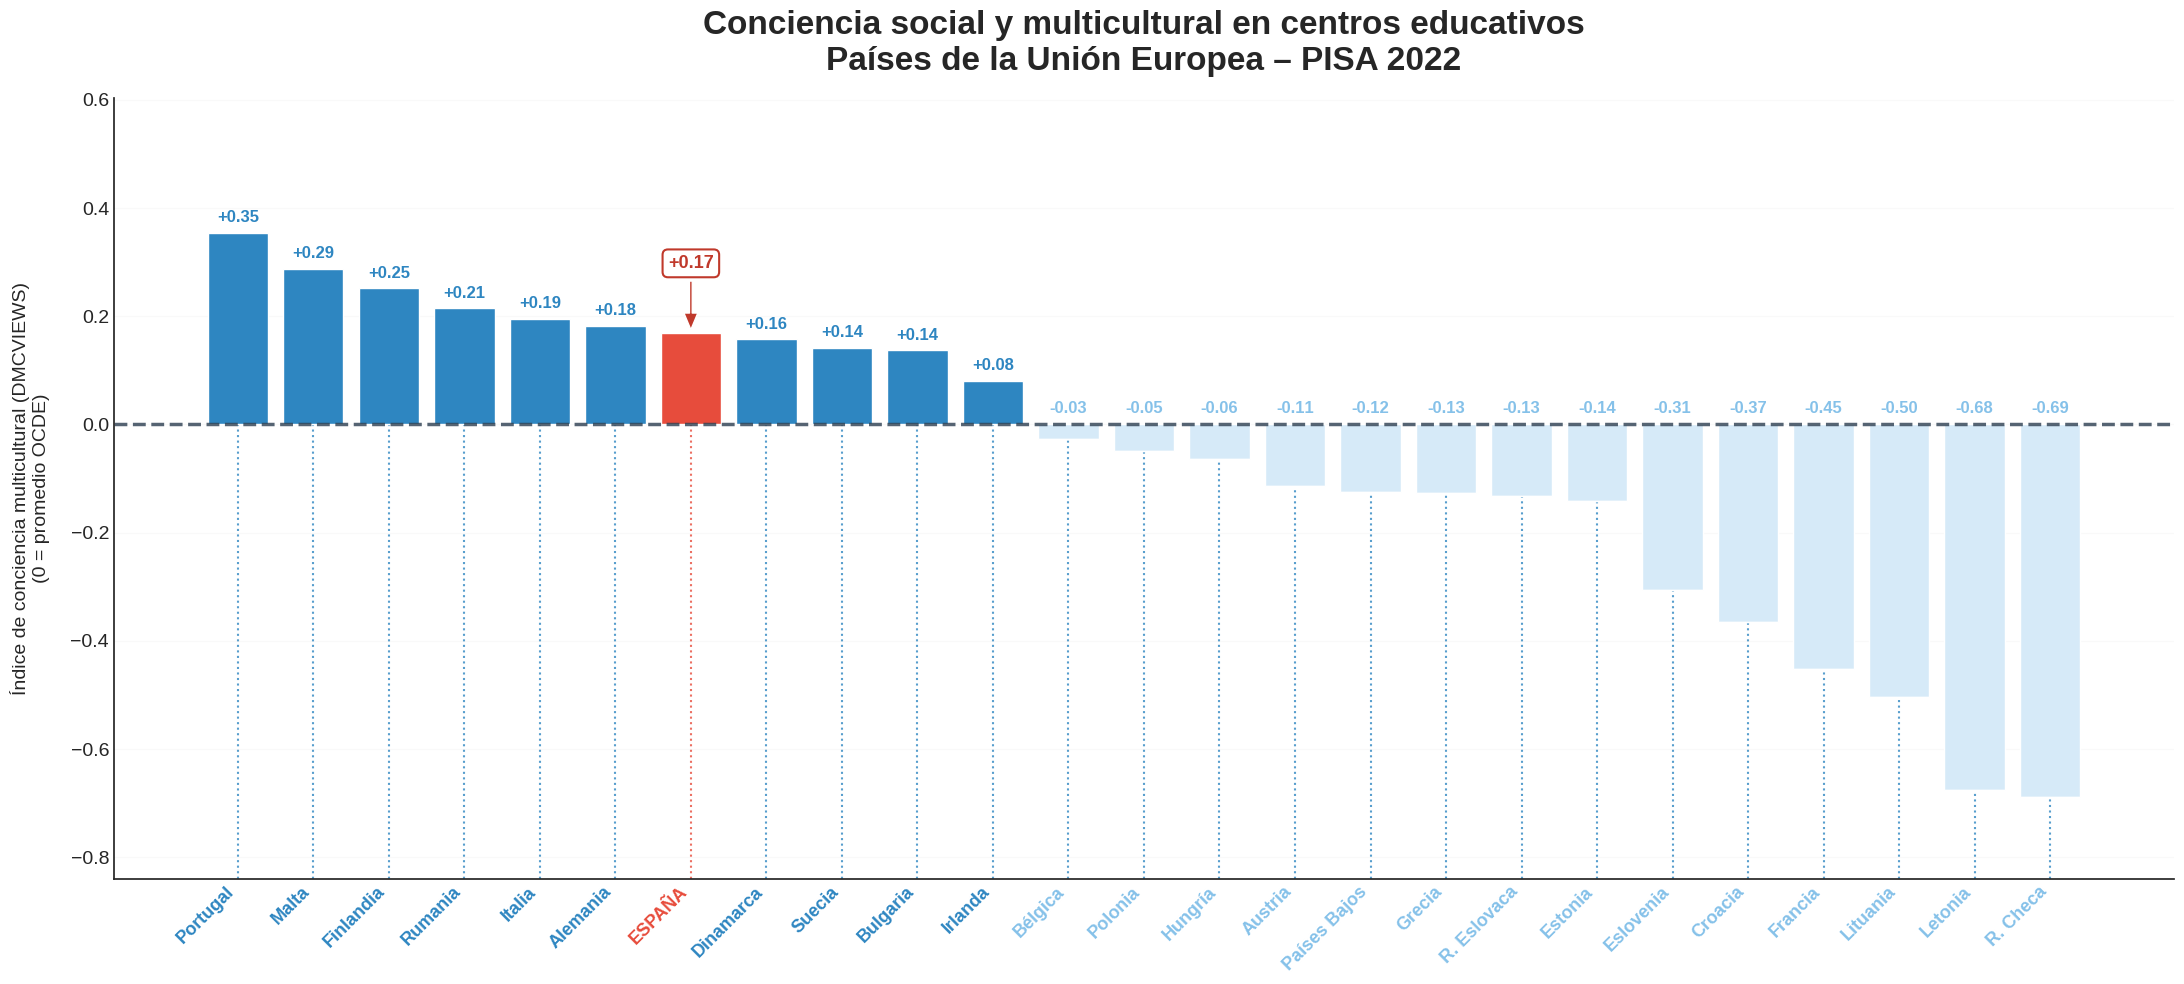

In [15]:
# =============================================================================
# 14. GRÁFICA PISA: CONCIENCIA SOCIAL
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd

# 14.1. PREPRACIÓN DE DATOS (BASADO EN EL DICCIONARIO DE 25 PAÍSES)
paises_finales = {
    'AUT': 'Austria', 'BEL': 'Bélgica', 'BGR': 'Bulgaria', 'CZE': 'R. Checa',
    'DEU': 'Alemania', 'DNK': 'Dinamarca', 'ESP': 'España', 'EST': 'Estonia',
    'FIN': 'Finlandia', 'FRA': 'Francia', 'GRC': 'Grecia', 'HRV': 'Croacia',
    'HUN': 'Hungría', 'IRL': 'Irlanda', 'ITA': 'Italia', 'LTU': 'Lituania',
    'LVA': 'Letonia', 'MLT': 'Malta', 'NLD': 'Países Bajos', 'POL': 'Polonia',
    'PRT': 'Portugal', 'ROU': 'Rumania', 'SVK': 'R. Eslovaca', 'SVN': 'Eslovenia',
    'SWE': 'Suecia'
}

# 14.2. DATASET PISA YA CARGADO PREVIAMENTE
df_tesis = df_pisa[df_pisa['CNT'].isin(paises_finales.keys())].copy()
df_tesis['Pais_Nombre'] = df_tesis['CNT'].map(paises_finales)

vars_needed = ['Pais_Nombre', 'DMCVIEWS']
df_plot_data = df_tesis[vars_needed].dropna()
df_country = df_plot_data.groupby('Pais_Nombre', as_index=False).mean()

# 14.3. LÓGICA DE LA GRÁFICA
df_plot = df_country.copy()
ref_ocde = 0
df_plot = df_plot.sort_values('DMCVIEWS', ascending=False).reset_index(drop=True)

df_plot['Base'] = df_plot['DMCVIEWS'].apply(lambda x: min(x, ref_ocde))
df_plot['Excedente'] = df_plot['DMCVIEWS'].apply(lambda x: max(0, x - ref_ocde))

plt.figure(figsize=(22, 10))
plt.style.use('seaborn-v0_8-white')

# Barras
colores_base = ['#FADBD8' if p == 'España' else '#D6EAF8' for p in df_plot['Pais_Nombre']]
plt.bar(df_plot['Pais_Nombre'], df_plot['Base'], color=colores_base)

colores_excedente = ['#E74C3C' if p == 'España' else '#2E86C1' for p in df_plot['Pais_Nombre']]
plt.bar(
    df_plot['Pais_Nombre'],
    df_plot['Excedente'],
    bottom=df_plot['Base'],
    color=colores_excedente
)

# Línea OCDE (0) — se mantiene
plt.axhline(y=0, color='#2C3E50', linestyle='--', linewidth=2.5, alpha=0.8)

# 14.4. ETIQUETAS NUMÉRICAS
for i, (pais, val) in enumerate(zip(df_plot['Pais_Nombre'], df_plot['DMCVIEWS'])):
    if pais == 'España':
        if val >= 0:
            plt.annotate(
                f'{val:+.2f}', xy=(i, val),
                xytext=(i, val + 0.12),
                arrowprops=dict(facecolor='#C0392B', shrink=0.05,
                                width=2, headwidth=10),
                ha='center', fontsize=13, fontweight='bold',
                color='#C0392B',
                bbox=dict(boxstyle="round,pad=0.3",
                          fc="white", ec="#C0392B", lw=1.5)
            )
        else:
            plt.text(
                i, 0.03, f'{val:+.2f}',
                ha='center', va='bottom',
                fontsize=13, fontweight='bold',
                color='#C0392B'
            )
    else:
        if val >= 0:
            plt.text(
                i, val + 0.02, f'{val:+.2f}',
                ha='center', fontsize=12,
                fontweight='bold', color='#2E86C1'
            )
        else:
            plt.text(
                i, 0.015, f'{val:+.2f}',
                ha='center', va='bottom',
                fontsize=12,
                fontweight='bold', color='#85C1E9'
            )

# 14.5. TÍTULOS Y EJES
plt.title(
    'Conciencia social y multicultural en centros educativos\nPaíses de la Unión Europea – PISA 2022',
    fontsize=24, pad=20, fontweight='bold'
)
plt.ylabel(
    'Índice de conciencia multicultural (DMCVIEWS)\n(0 = promedio OCDE)',
    fontsize=14, labelpad=15
)

plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=14)

# 14.6. ESTILO DE NOMBRES EN EJE X (ESPAÑA EN MAYÚSCULAS)
ax = plt.gca()
labels = []

for i, tick in enumerate(ax.get_xticklabels()):
    pais = tick.get_text()
    val = df_plot.loc[i, 'DMCVIEWS']

    if pais == 'España':
        labels.append('ESPAÑA')
        tick.set_fontweight('bold')
        tick.set_color('#E74C3C')
    elif val >= 0:
        labels.append(pais)
        tick.set_fontweight('bold')
        tick.set_color('#2E86C1')
    else:
        labels.append(pais)
        tick.set_fontweight('bold')
        tick.set_color('#85C1E9')

ax.set_xticklabels(labels)

# 14.7. LÍMITES DEFINITIVOS DEL EJE Y
y_min = df_plot['DMCVIEWS'].min() - 0.15
y_max = df_plot['DMCVIEWS'].max() + 0.25
plt.ylim(y_min, y_max)

# 14.8. LÍNEAS VERTICALES PUNTEADAS HASTA LA BASE REAL
for i, pais in enumerate(df_plot['Pais_Nombre']):
    color_linea = '#E74C3C' if pais == 'España' else '#2E86C1'
    plt.vlines(
        x=i,
        ymin=0,
        ymax=y_min,
        colors=color_linea,
        linestyles=':',
        linewidth=1.5,
        alpha=0.8,
        zorder=0
    )

plt.grid(axis='y', alpha=0.1)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Lectura e interpretación de la visualización**

La gráfica muestra la posición relativa de los países de la Unión Europea respecto al índice de conciencia multicultural (DMCVIEWS), tomando como referencia el promedio OCDE, fijado en el valor cero. Los valores positivos indican un entorno escolar con actitudes y prácticas más favorables hacia la diversidad y la multiculturalidad, mientras que los valores negativos reflejan una menor presencia de estos elementos.

Se observa una distribución claramente asimétrica, con un grupo reducido de países que se sitúan de forma consistente por encima del promedio y un bloque más amplio con valores por debajo de la referencia. Esta dispersión confirma que la conciencia multicultural en los centros educativos no es homogénea dentro del espacio europeo.

España se posiciona en el grupo de países con valores positivos, situándose moderadamente por encima del promedio OCDE. Esta ubicación indica que, en términos relativos, el entorno educativo español presenta niveles de conciencia multicultural superiores a la media, aunque sin alcanzar los valores más altos observados en el conjunto europeo.

El contraste entre países con valores elevados y aquellos con índices claramente negativos pone de relieve que la gestión de la diversidad en el ámbito escolar depende de factores estructurales, institucionales y culturales específicos de cada contexto nacional.

En relación con el marco conceptual del proyecto, esta visualización aporta un elemento clave: un nivel relativamente alto de conciencia multicultural en el entorno educativo puede coexistir con incrementos en determinados tipos de delitos de odio. Este resultado refuerza la necesidad de una lectura compleja del fenómeno, en la que la educación y la conciencia social actúan como factores mediadores —en la identificación, denuncia y registro— más que como garantías automáticas de reducción del conflicto social.


### **15. Preparación del indicador PISA para análisis correlacional**

Este bloque tiene como objetivo preparar el índice de conciencia multicultural (DMCVIEWS) para su uso en análisis comparativos y correlacionales a nivel país.

Hasta este punto, el índice se ha utilizado con fines descriptivos y visuales. Sin embargo, para poder relacionarlo con otras variables —como indicadores de delitos de odio u otros factores contextuales— es necesario transformarlo en una estructura agregada y consistente.

En este bloque:

- Se filtran los datos PISA para mantener únicamente los países seleccionados en el análisis.
- Se mapea el código de país a su nombre completo para facilitar la interpretación.
- Se eliminan los registros con valores nulos en el índice DMCVIEWS.
- Se calcula el valor medio del índice por país, obteniendo una medida sintética y comparable del nivel de conciencia multicultural en el entorno educativo.

El resultado es un ranking de países basado en el índice DMCVIEWS, que servirá como variable independiente en los análisis correlacionales posteriores. Este paso garantiza que las comparaciones se realicen sobre datos homogéneos y metodológicamente coherentes.


In [16]:
# =============================================================================
# 15.PREPARACIÓN PISA PARA CORRELACIÓN
# =============================================================================

# 15.1 USAMOS EL MISMO df_pisa QUE YA TENEMOS
df_tesis = df_pisa[df_pisa['CNT'].isin(paises_finales.keys())].copy()
df_tesis['Pais_Nombre'] = df_tesis['CNT'].map(paises_finales)

ranking_pisa = (
    df_tesis
    .dropna(subset=['DMCVIEWS'])
    .groupby('Pais_Nombre')['DMCVIEWS']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)


### **16. Análisis exploratorio de correlación: educación superior y conciencia social**

Este bloque introduce un análisis exploratorio orientado a examinar la relación entre dos variables de contexto previamente analizadas de forma independiente: el nivel de educación superior y el índice de conciencia social y multicultural (DMCVIEWS).

El objetivo no es establecer una relación causal, sino identificar patrones de asociación y posicionamiento relativo entre países dentro del espacio europeo. Para ello, se integran ambos indicadores en una única estructura de datos a nivel país, permitiendo su comparación directa.

En este bloque:

- Se combinan los datos de educación superior (2024) con el índice DMCVIEWS de PISA (2022) mediante una unión por país.
- Se construye una visualización bidimensional que representa simultáneamente ambas variables.
- Se definen cuadrantes de lectura que facilitan la interpretación cualitativa de los distintos perfiles nacionales.
- Se destaca explícitamente el caso de España para contextualizar su posición dentro del conjunto europeo.

Este enfoque permite analizar la relación entre educación y conciencia social desde una perspectiva comparativa y estructural, sentando las bases para una interpretación prudente de los resultados.


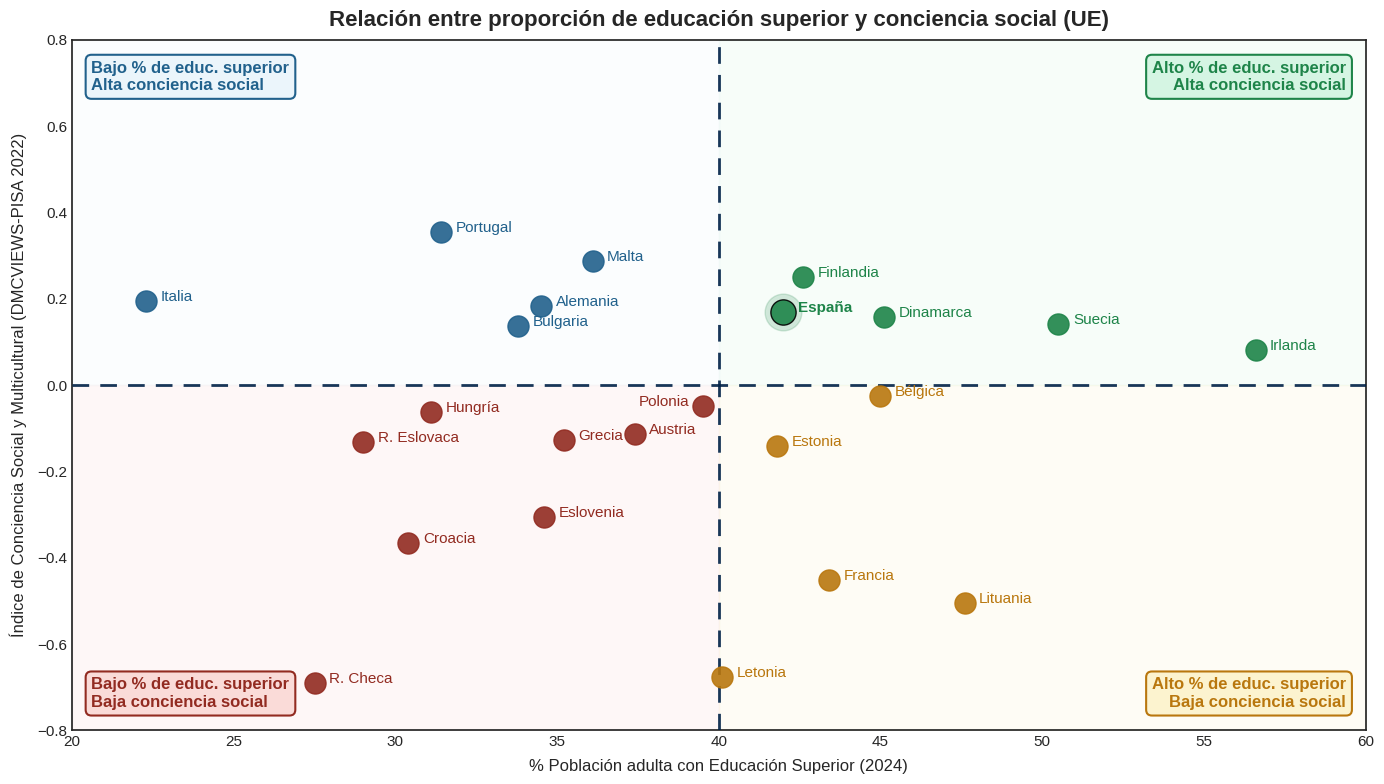

El Coeficiente de Correlación de Pearson es: 0.055


In [17]:
# =============================================================================
# 16. GRÁFICA DE CORRELACIÓN: EDUCACIÓN VS CONCIENCIA (EXPORTABLE)
# =============================================================================

import matplotlib.pyplot as plt
import pandas as pd

# 16.1. CORRECCIÓN DE REFERENCIA
df_todos = df_paises

# 16.2. PREPARACIÓN DE DATOS PARA LA UNIÓN (MERGE)
ranking_pisa_copy = ranking_pisa.copy()
ranking_pisa_copy.columns = ['País', 'Indice_Diversidad']

df_correlacion = pd.merge(df_todos, ranking_pisa_copy, on='País', how='inner')

# 16.3. CONFIGURACIÓN DE LA FIGURA
fig, ax = plt.subplots(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# 16.4. PARÁMETROS FIJOS EXACTOS
x_mid = 40
y_mid = 0
x_min, x_max = 20, 60
y_min, y_max = -0.8, 0.8

x_margin = (x_max - x_min) * 0.015
y_margin = (y_max - y_min) * 0.03

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# 16.5. FONDOS DE LOS CUADRANTES
ax.fill_between([x_mid, x_max], y_mid, y_max, color='#D5F5E3', alpha=0.18, zorder=0)
ax.fill_between([x_min, x_mid], y_min, y_mid, color='#FADBD8', alpha=0.20, zorder=0)
ax.fill_between([x_mid, x_max], y_min, y_mid, color='#FCF3CF', alpha=0.20, zorder=0)
ax.fill_between([x_min, x_mid], y_mid, y_max, color='#EBF5FB', alpha=0.20, zorder=0)

# 16.6. LÍNEAS DE CUADRANTES
ax.axvline(x_mid, color='#002147', linestyle=(0, (6, 4)), linewidth=2.0, alpha=0.9, zorder=3)
ax.axhline(y_mid, color='#002147', linestyle=(0, (6, 4)), linewidth=2.0, alpha=0.9, zorder=3)

# 16.7. PUNTOS Y ETIQUETAS
for _, row in df_correlacion.iterrows():
    x, y = row['Total_num'], row['Indice_Diversidad']

    if x >= x_mid and y >= y_mid: color = '#1E8449'
    elif x < x_mid and y < y_mid: color = '#922B21'
    elif x >= x_mid and y < y_mid: color = '#B9770E'
    else: color = '#21618C'

    if row['País'] == 'España':
        ax.scatter(x, y, s=700, color=color, alpha=0.18, zorder=4)

    size = 330 if row['País'] == 'España' else 230
    edge = 'black' if row['País'] == 'España' else None

    ax.scatter(x, y, s=size, color=color, edgecolors=edge, alpha=0.90, zorder=5)

    if row['País'] == 'Polonia':
        text_x, ha = x - 0.4, 'right'
    else:
        text_x, ha = x + 0.45, 'left'

    ax.text(
        text_x, y, row['País'],
        fontsize=11, ha=ha, zorder=6,
        fontweight='bold' if row['País'] == 'España' else 'normal',
        color=color
    )

# 16.8. CAJAS DE TEXTO
estilo_caja = dict(boxstyle="round,pad=0.35", lw=1.5)

ax.text(x_max - x_margin, y_max - y_margin,
        'Alto % de educ. superior\nAlta conciencia social',
        ha='right', va='top', fontsize=12, fontweight='bold', color='#1E8449',
        bbox={**estilo_caja, 'fc': "#D5F5E3", 'ec': "#1E8449"}, zorder=10)

ax.text(x_min + x_margin, y_max - y_margin,
        'Bajo % de educ. superior\nAlta conciencia social',
        ha='left', va='top', fontsize=12, fontweight='bold', color='#21618C',
        bbox={**estilo_caja, 'fc': "#EBF5FB", 'ec': "#21618C"}, zorder=10)

ax.text(x_max - x_margin, y_min + y_margin,
        'Alto % de educ. superior\nBaja conciencia social',
        ha='right', va='bottom', fontsize=12, fontweight='bold', color='#B9770E',
        bbox={**estilo_caja, 'fc': "#FCF3CF", 'ec': "#B9770E"}, zorder=10)

ax.text(x_min + x_margin, y_min + y_margin,
        'Bajo % de educ. superior\nBaja conciencia social',
        ha='left', va='bottom', fontsize=12, fontweight='bold', color='#922B21',
        bbox={**estilo_caja, 'fc': "#FADBD8", 'ec': "#922B21"}, zorder=10)

# 16.9. TÍTULOS Y EJES
ax.set_title(
    'Relación entre proporción de educación superior y conciencia social (UE)',
    fontsize=16, pad=10, fontweight='bold'
)
ax.set_xlabel('% Población adulta con Educación Superior (2024)', fontsize=12, labelpad=7)
ax.set_ylabel('Índice de Conciencia Social y Multicultural (DMCVIEWS-PISA 2022)', fontsize=12, labelpad=7)

plt.tight_layout()
plt.show()

# 16.10. CÁLCULO DE COEFICIENTE DE PEARSON (DE CORRELACIÓN)
correlacion = df_correlacion['Total_num'].corr(df_correlacion['Indice_Diversidad'])
print(f"El Coeficiente de Correlación de Pearson es: {correlacion:.3f}")


**Lectura e interpretación del análisis correlacional**

La visualización muestra la relación entre la proporción de población adulta con educación superior y el índice de conciencia social y multicultural (DMCVIEWS), estructurada mediante un sistema de cuadrantes que facilita la lectura comparativa entre países de la Unión Europea.

La dispersión de los puntos confirma que no existe una relación lineal clara entre ambas variables. Países con niveles elevados de educación superior aparecen tanto en contextos de alta como de baja conciencia social, y del mismo modo, algunos países con menor proporción de educación superior presentan valores relativamente altos en el índice de conciencia multicultural.

El coeficiente de correlación de Pearson obtenido es bajo, lo que respalda cuantitativamente esta lectura visual y refuerza la idea de que el nivel educativo agregado, por sí solo, no explica las diferencias observadas en conciencia social entre países.

La posición de España resulta especialmente significativa: se sitúa en el cuadrante de **alto nivel de educación superior y conciencia social positiva**, aunque sin destacar como un valor extremo dentro del conjunto europeo. Esto sugiere un contexto educativo y social favorable, pero comparable al de otros países con perfiles similares.

El análisis por cuadrantes pone de relieve la coexistencia de distintos modelos nacionales:
- países con alto nivel educativo y alta conciencia social,
- países con alto nivel educativo pero conciencia social reducida,
- y contextos con menor nivel educativo donde la conciencia social adopta comportamientos diversos.

En conjunto, esta visualización refuerza el enfoque central del proyecto: la educación superior constituye un factor relevante de contexto, pero su relación con la conciencia social es compleja y mediada por elementos institucionales, culturales y sociales. La ausencia de una correlación fuerte subraya la necesidad de evitar explicaciones simplistas y de adoptar una lectura multidimensional del fenómeno analizado.


## **17. Conclusiones**

El análisis desarrollado a lo largo de este notebook ha permitido abordar el fenómeno de los delitos de odio desde una perspectiva multidimensional, integrando datos temporales, tipológicos, territoriales y de contexto educativo y social. A partir de este enfoque, se pueden extraer varias conclusiones clave.

En primer lugar, el incremento sostenido de los delitos de odio registrados no puede interpretarse de forma directa como un aumento equivalente del odio social. Tal como muestran los datos, un mayor número de registros puede estar asociado, en parte, a una mayor capacidad de identificación, denuncia y registro institucional de estos hechos. En este sentido, más registros no implican necesariamente más odio, sino una mayor visibilidad del fenómeno.

En segundo lugar, los análisis sugieren que la educación y la conciencia social desempeñan un papel relevante como factores mediadores. Un mayor nivel educativo y un entorno escolar con actitudes más favorables hacia la diversidad pueden contribuir a que las conductas discriminatorias sean reconocidas y denunciadas con mayor frecuencia, mejorando su reflejo en las estadísticas oficiales. Esto refuerza la idea de que los datos registrados dependen no solo de la incidencia real, sino también de los mecanismos sociales e institucionales que permiten hacerla visible.

Por el contrario, bajos niveles de denuncia o registro no garantizan una menor incidencia de delitos de odio. En determinados contextos, pueden reflejar procesos de invisibilización, normalización o falta de conciencia social, en los que las conductas discriminatorias no llegan a identificarse como tales o no se traducen en denuncias formales.

El análisis correlacional entre educación superior y conciencia social muestra, además, que no existe una relación lineal fuerte entre ambas variables. Este resultado subraya la necesidad de evitar explicaciones simplistas y confirma que los fenómenos sociales complejos no pueden entenderse a partir de una única variable explicativa.

Finalmente, este trabajo pone de relieve una cuestión fundamental desde el punto de vista ético y analítico: los datos permiten identificar patrones y tendencias, pero no justifican ni normalizan el odio. Detrás de cada punto, cada registro y cada outlier hay realidades humanas que no deben perderse de vista en el análisis cuantitativo.

En conjunto, los resultados refuerzan la importancia de abordar los delitos de odio desde una lectura crítica y contextualizada, en la que la educación, la conciencia social y la calidad de los sistemas de registro se entiendan como piezas clave para interpretar correctamente los datos y orientar políticas públicas más eficaces.


## **18. Call to Action (CTA)**

Este análisis no busca ofrecer respuestas definitivas, sino que **propone un llamado a la reflexión crítica** sobre cómo interpretamos y respondemos al fenómeno de los delitos de odio. Los datos revelan tendencias, pero no hablan por sí solos: **somos nosotros quienes decidimos cómo mirarlos, qué preguntas hacer y qué decisiones tomar a partir de ellos**.

Una mayor visibilidad estadística no implica necesariamente un aumento del odio, sino que puede reflejar una sociedad más atenta, más consciente y más dispuesta a nombrar lo que antes se silenciaba. Identificar, registrar y visibilizar un delito es ya un primer acto de justicia.

Por eso, el verdadero desafío no es solo reducir cifras, sino reconocer lo que antes no se veía. Es romper la indiferencia. Es dejar de mirar hacia otro lado cuando no somos los afectados directos. Es entender que **callarse también es una forma de contribuir al problema**.

Este trabajo invita a tomar partido: por la empatía, por la responsabilidad colectiva, por la educación como herramienta de transformación. Porque detrás de cada categoría hay una experiencia vivida. Y detrás de cada outlier, una persona.

**Los datos explican tendencias. Pero no justifican el odio.**  
Comprender esta diferencia es el primer paso para no quedarnos al margen.